In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec

In [2]:
class TickProperties():
    
    major_xtick_step = 5,
    minor_xtick_step = 1
    major_ytick_step = 5
    minor_ytick_step = 1
    STRIP_OF_ZEROS_X = False
    STRIP_OF_ZEROS_Y = False

    def __init__(self,\
    xtick_step_major = 5,\
    xtick_step_minor = 1,\
    ytick_step_major = 5,\
    ytick_step_minor = 1,\
    SZX = False,\
    SZY = False):
        self.major_xtick_step = xtick_step_major
        self.minor_xtick_step = xtick_step_minor
        self.major_ytick_step = ytick_step_major
        self.minor_ytick_step = ytick_step_minor
        self.STRIP_OF_ZEROS_X = SZX
        self.STRIP_OF_ZEROS_Y = SZY

class Format():
    numb_xticks = None
    numb_yticks = None
    custom_func_x = None
    custom_func_y = None
    x_scale = None
    y_scale = None
    x_precion = "{:.2f}"
    y_precion = "{:.2f}"
    def __init__(self,numb_xticks=None,numb_yticks=None,custom_funx=None,custom_funy=None,xscale=None,yscale=None,xprec="{:.2f}",yprec="{:.2f}"):
        self.numb_xticks =numb_xticks
        self.numb_yticks = numb_yticks
        self.custom_func_x = custom_funx
        self.custom_func_y = custom_funy
        self.x_precion=xprec
        self.y_precion = yprec
        self.x_scale = xscale
        self.y_scale = yscale
    def formatx0(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))
            # print(x,pos,self.numb_xticks)
            index = int((pos-1)*self.x_scale.shape[0]//self.numb_xticks)
            # print(index)
            # print(self.x_precion.format(self.x_scale[index]))
            return self.x_precion.format(self.x_scale[index])
        except:
            return self.x_precion.format(self.x_scale[-1])
    def formatx1(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))
            # print(pos)
            index = int((pos)*self.x_scale.shape[0]//self.numb_xticks)
            # print(index)
            # print()
            return self.x_precion.format(self.x_scale[index])
        except:
            return self.x_precion.format(self.x_scale[-1])
    
    def formaty1(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))

            index = int((pos-1)*self.y_scale.shape[0]//self.numb_yticks)
            # print(index)
            # print()
            return self.y_precion.format(self.y_scale[index])
        except:
            return self.y_precion.format(self.y_scale[-1])
        
    def formaty(self,x,pos):
        try:
            return self.y_precion.format(self.y_scale[int(x)])
        except:
            return ""

class Setup_Fig():
    DEFAULT_HEAT_EXTEND = (-0.5,39.5,29.5,-0.5)
    xlim = None
    ylim = None
    tickprop = TickProperties()
    formatter = Format()
    cm = 1/2.54 
    fig_width = 12*cm
    fig_height = 4.8/6.4*12*cm
    name_of_plot = None
    def __init__(self,name_of_plot = "sign_of_ev1.pdf",xlim=None,ylim=None,tickp=TickProperties(),formater=Format()):
        self.xlim=xlim
        self.ylim = ylim   
        self.tickprop =tickp       
        self.formatter = formater
        self.name_of_plot = name_of_plot

    
    plt.rcParams["lines.markersize"]=1
    plt.rcParams["axes.unicode_minus"]=True
    plt.rcParams["font.size"]=10
    plt.rcParams["text.usetex"]=True
    plt.rcParams["font.serif"]="Computer Modern Serif"
# ax.scatter(A,root,color='0')
    



    def return_fig(self,shape=(1,1),dots_per_inch=400,xax_share=False,yax_share=False,joined=False,set_ticks=True,heightratio=None):
        if heightratio:
            fig, ax = plt.subplots(*shape,figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch,sharex=xax_share,sharey=yax_share,height_ratios=heightratio)
        else:
            fig, ax = plt.subplots(*shape,figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch,sharex=xax_share,sharey=yax_share)
        trash, xw, yw, trash=self.DEFAULT_HEAT_EXTEND# im.get_extent()
        self.formatter.numb_xticks = xw//self.tickprop.major_xtick_step
        self.formatter.numb_yticks = yw//self.tickprop.major_ytick_step
        
        for i in range(shape[0]):
            for j in range(shape[1]):
                pos= 'outer_left'
                if shape[0]==1:
                    if shape[1]==1:
                        current_ax = ax
                    else:
                        current_ax = ax[j]
                else:
                    if shape[1]==1:
                        current_ax = ax[i]
                    else:
                        current_ax = ax[i,j]
                        if j==0:
                           pos= 'outer_left'
                        elif j<shape[1]-1:
                            pos = 'middle'
                        elif j==shape[1]-1:
                            pos = 'outer_right'
                        


        # axlimits have to be adapted
                try:
                    current_ax.set_xlim(*self.xlim)
                except:
                    pass
                try:
                    current_ax.set_ylim(*self.ylim)
                except:
                    pass    
            
                if set_ticks:
                    if self.tickprop.STRIP_OF_ZEROS_X:
                        current_ax.xaxis.set_major_formatter(ticker.FuncFormatter(self.formatter.formatx0))
                    current_ax.yaxis.set_major_locator(ticker.MultipleLocator(self.tickprop.major_ytick_step))
                    current_ax.yaxis.set_minor_locator(ticker.MultipleLocator(self.tickprop.minor_ytick_step))
                    current_ax.xaxis.set_major_locator(ticker.MultipleLocator(self.tickprop.major_xtick_step))
                    current_ax.xaxis.set_minor_locator(ticker.MultipleLocator(self.tickprop.minor_xtick_step))

                    if self.tickprop.STRIP_OF_ZEROS_Y:
                        current_ax.yaxis.set_major_formatter(ticker.FuncFormatter(self.formatter.formaty1))  

                if joined:
                    if i<shape[0]-1:
                        current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=False)
                    else:
                        current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
                        
                    if pos=='outer_left':
                        current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=True)
                    elif pos=='middle':
                        current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=False)
                    elif pos=='outer_right':
                        current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelright=True)
                        # current_ax.set_xlabel(r'$\Gamma \tilde{A}$')
                        # current_ax.set_ylabel(r'$\tilde{y}$',rotation=0)
                else:
                    current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
                    
                    current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=True)   


                current_ax.tick_params(axis='both',which='major',length=4.5)
                plt.setp(current_ax.yaxis.get_majorticklabels(),va='center')
        
        return fig, ax

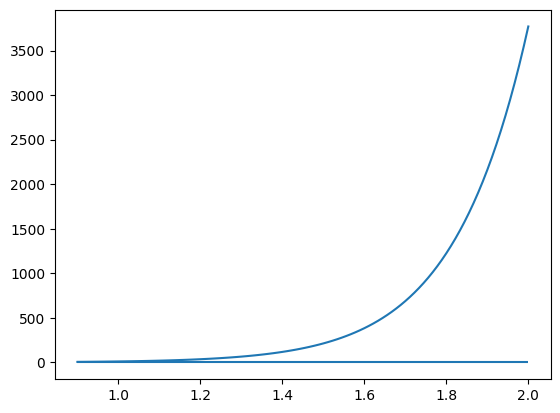

In [2]:
def func(x):
    return (1-(7*x**2-1)/x**2/8)*(1+(7*x**2-1)/8)**7-x**10

fig, ax1 = plt.subplots(1,1)
x = np.linspace(0.9,2,100)
ax1.plot(x,func(x))
ax1.hlines(0,x[0],x[-1])
plt.show()

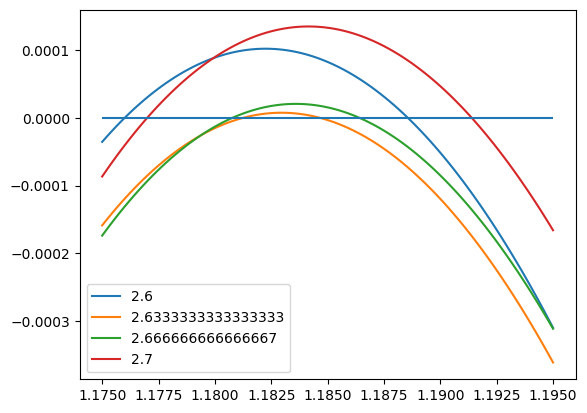

In [30]:
def func(r,phi):
    return np.cos(phi)-r**6/np.sqrt(1+r**2*np.sin(phi)**2)**7
fig, ax1 = plt.subplots(1,1)
phi = np.linspace(1.175,1.195,100)
# er = np.zeros((2,len(phi)))
# er[0,:] = np.cos(phi)
# er[1,:] = np.sin(phi)
r = np.linspace(2.6,2.7,4)


for i in range(len(r)):

    ax1.plot(phi,func(r[i],phi),label=f"{r[i]}")
ax1.hlines(0,phi[0],phi[-1])
ax1.legend()
plt.show()

      converged: True
           flag: converged
 function_calls: 44
     iterations: 22
           root: 2.6457512891338317
         method: newton


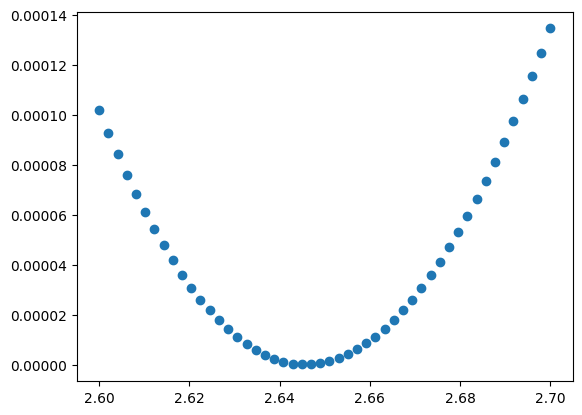

In [29]:
def func(y,r):
    x = y**2*r**2+1
    b = 7*r**8
    return x**9+b**2/r**2*x-b**2*(1+1/r**2)
from scipy.optimize import root_scalar
def rooty(r):
    rt = root_scalar(func,args=(r),x0=0.5)
    return rt.root
def maxi(r,x):
    return np.sqrt(1-x**2)-r**6/np.sqrt(1+r**2*x**2)**7
r = np.linspace(2.6,2.7)
roots = np.zeros_like(r)
maxima = np.zeros_like(r)
for i in range(len(r)):
    roots[i] = rooty(r[i])
    maxima[i] = maxi(r[i],roots[i])

def maximum(r):
    return maxi(r,rooty(r))
print(root_scalar(maximum,x0=2.6))
fig, ax = plt.subplots(1,1)
ax.scatter(r,maxima)
plt.show()


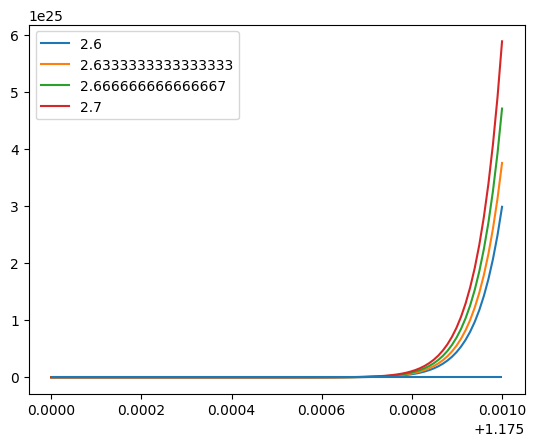

In [ ]:
def func(r,phi):
    return np.sin(phi)*np.cos(phi)/r**5-r*np.sin(phi)/np.sqrt(1+r**2*np.sin(phi)**2)**7
fig, ax1 = plt.subplots(1,1)
phi = np.linspace(1.175,1.176,100)
# er = np.zeros((2,len(phi)))
# er[0,:] = np.cos(phi)
# er[1,:] = np.sin(phi)
r = np.linspace(2.6,2.7,4)

def func(r,x):
    return x**9+7*r**6*x-7*r**8*(1+1/r**2)
for i in range(len(r)):
    x = np.linspace(0,10,100)**2*r[i]**2+1
    ax1.plot(phi,func(r[i],x),label=f"{r[i]}")
ax1.hlines(0,phi[0],phi[-1])
ax1.legend()
plt.show()

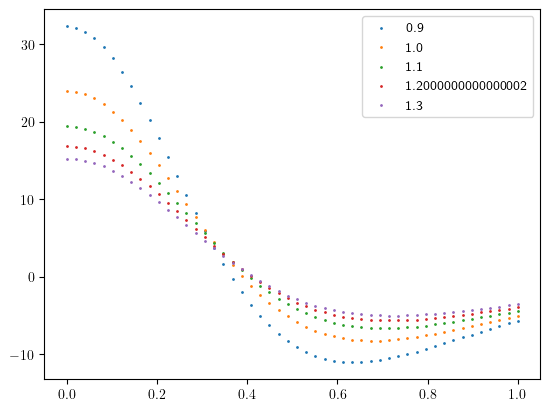

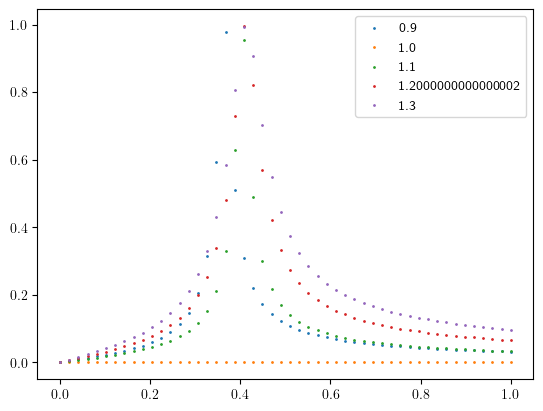

In [3]:
def d_1(a,e,d):
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    A = 12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9)
    B = 15*(a*e/r1**7-e/r2**7)
    res =  B**2*(1-d**2)/(A**2*d**2+B**2*(1-d**2))
    return A, B, np.sqrt(res)
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
x = np.linspace(0,1)
alphas = np.linspace(0.9,1.3,5)
# alphas = [2.646]
d = 0.9
for i in range(len(alphas)):
    ax.scatter(x,d_1(alphas[i],x,d)[0],label=f"{alphas[i]}")
    ax2.scatter(x,d_1(alphas[i],x,d)[2],label=f"{alphas[i]}")
ax.legend()
ax2.legend()
plt.show()

0.11209940586114017
0.22938380978130846


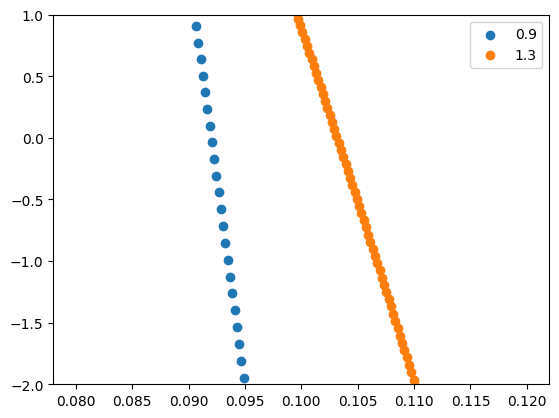

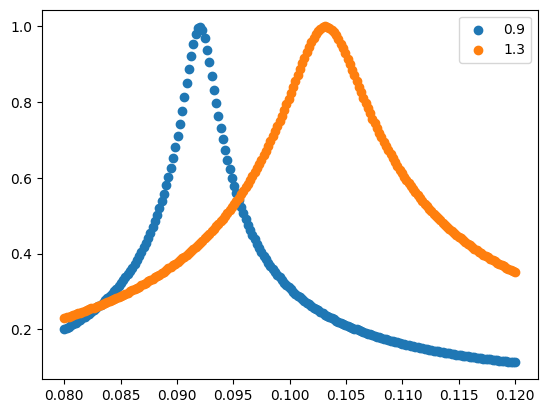

In [8]:
def func(e,a,d):
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    A = 12*(1/r1**5+1/r2**5-7*15*(a**2*e**2/r1**9+e**2/r2**9))
    B = 15*(a*e/r1**7-e/r2**7)
    res1 = -B**2/2/(A**2-B**2)/d**2
    res2 = 1/2/(A**2-B**2)/d**2*np.sqrt(B**4-4*(A**2-B**2)*d**2*(d**2-1)*B**2)
    return A, B, res1+res2
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
x = np.linspace(0.08,0.12,200)
alphas = np.linspace(0.9,1.3,2)
d = 0.5
for i in range(len(alphas)):
    ax.scatter(x,func(x,alphas[i],d)[0],label=f"{alphas[i]}")
    ax2.scatter(x,func(x,alphas[i],d)[2],label=f"{alphas[i]}")
    print(np.min(func(x,alphas[i],d)[2]))
ax.set_ylim(-2,1)
ax.legend()
ax2.legend()
plt.show()

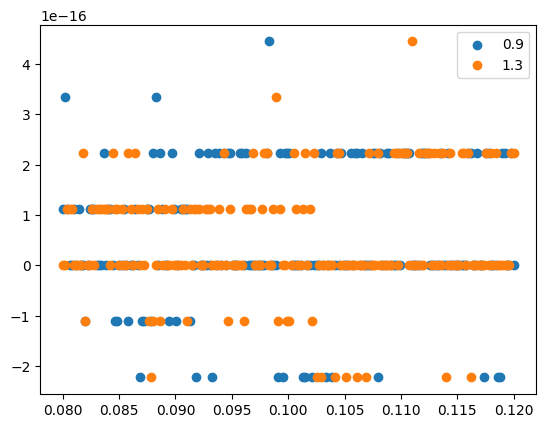

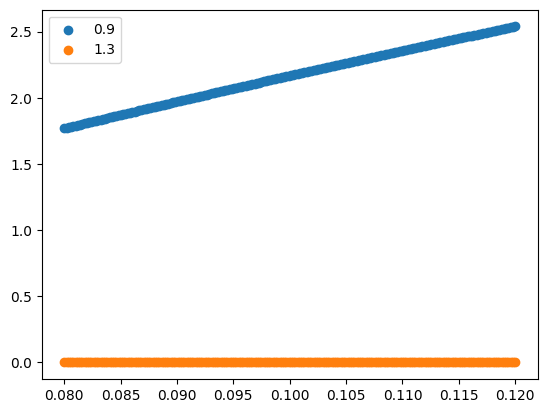

In [ ]:
def vxy1(alpha,e,d):
    A,B, d1 = d_1(alpha,e,d)
    return d1*d*A-np.sign(A*B)*B*np.sqrt(1-d1**2)*np.sqrt(1-d**2)
def vxy2(alpha,e,d):
    A,B, d1 = d_1(alpha,e,d)
    return d1*d*A+B*np.sqrt(1-d1**2)*np.sqrt(1-d**2)
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
x = np.linspace(0.08,0.12,200)
alphas = np.linspace(0.9,1.3,2)
d = 0.5
for i in range(len(alphas)):
    ax.scatter(x,vxy1(alphas[i],x,d),label=f"{alphas[i]}")
    ax2.scatter(x,vxy2(alphas[i],x,d),label=f"{alphas[i]}")
    # ax2.scatter(x,vxy(alphas[i],d)[2],label=f"{alphas[i]}")
    # print(np.min(func(x,alphas[i],d)[1]))
# ax.set_ylim(-2,1)
ax.legend()
ax2.legend()
plt.show()

/tmp/ipykernel_4558/4115039790.py:53: RuntimeWarning: invalid value encountered in divide
  ax2[i//2,i%2].scatter(phi,np.arctan(yy/xx)+np.sign(yy)*np.pi*(1-np.sign(xx))/2,label=f"{alphas[i]}")


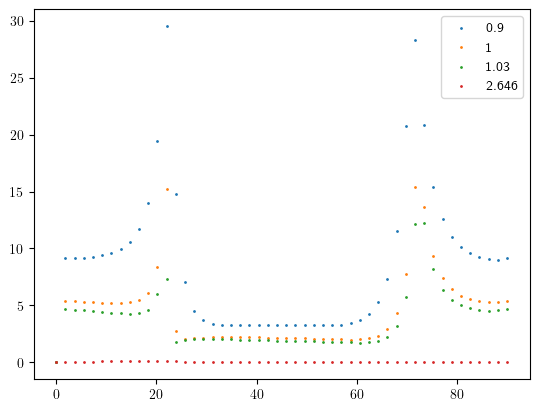

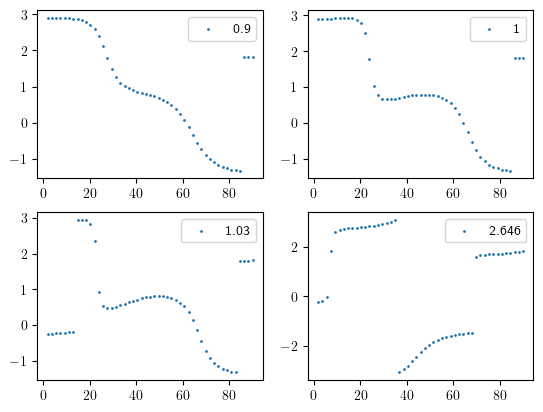

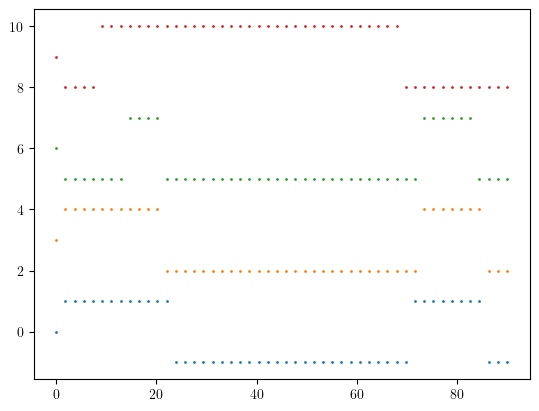

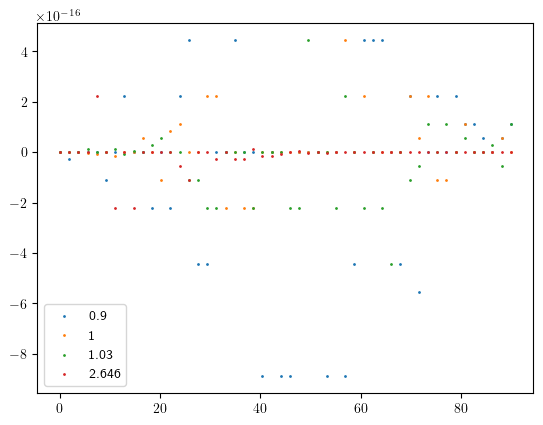

In [4]:
def interaction_rotated(DelR,i,j,d2,cut):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    # if r ==0:
    #     return 0
    # if r>cut+0.01:
        # return 0
    Am, Bm, d1 = d_1(DelR[0],DelR[1],d2)
    if i==j:
        B = -3/r**5+15*DelR[i]**2/r**7
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        return A*d1*d2 -np.sign(Am*Bm)* B*np.sqrt(1-d1**2)*np.sqrt(1-d2**2)
    else:
        return d1*d2*Am-np.sign(Am*Bm)*Bm*np.sqrt(1-d1**2)*np.sqrt(1-d2**2)

def vxx(e,a,d):
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    Am, Bm, d1 = d_1(a,e,d)
    A = 30*(a*e/r1**7-e/r2**7)-7*15*(a**3*e/r1**9-e/r2**9)
    B = -3*(1/r1**5+1/r2**5)+15*(a**2/r1**7+1/r2**7)
    res = A*d1*d-np.sign(Am*Bm)*B*np.sqrt(1-d1**2)*np.sqrt(1-d**2)
    return A, B, res

def vyy(e,a,d):
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    Am, Bm, d1 = d_1(a,e,d)
    A = 30*(a*e/r1**7-e/r2**7)-7*15*(a*e**3/r1**9-e**3/r2**9)
    B = -3*(1/r1**5+1/r2**5)+15*(e**2/r1**7+e**2/r2**7)
    res = A*d1*d-np.sign(Am*Bm)*B*np.sqrt(1-d1**2)*np.sqrt(1-d**2)
    return np.sign(Bm*Am), res

fig, ax = plt.subplots(1,1)
# fig2, ax2 = plt.subplots(1,1)
fig2, ax2 = plt.subplots(2,2)
fig3, ax3 = plt.subplots(1,1)
fig4, ax4 = plt.subplots(1,1)
x = np.linspace(0.08,0.12)
# phi = np.linspace(0,np.pi/2)/np.pi*180
phi = np.linspace(0,90)
# alphas = np.linspace(0.9,1.3,4)
alphas = [0.9,1,1.03,2.646]
# alphas = [2.646]
d = 0.9

er = np.zeros((2,len(phi)))
er[0,:] = np.cos(phi/180*np.pi)
er[1,:] = np.sin(phi/180*np.pi)
for i in range(len(alphas)):
    yy = interaction_rotated(alphas[i]*er,1,1,d,100)
    xx = interaction_rotated(alphas[i]*er,0,0,d,100)
    ax.scatter(phi,np.sqrt(xx**2+yy**2),label=f"{alphas[i]}")
    ax2[i//2,i%2].scatter(phi,np.arctan(yy/xx)+np.sign(yy)*np.pi*(1-np.sign(xx))/2,label=f"{alphas[i]}")
    # ax2.scatter(phi,interaction_rotated(alphas[i]*er,0,0,d,100),label=f"{alphas[i]}")
    # ax.scatter(phi,xx,label=f"{alphas[i]}")
    # ax2.scatter(phi,yy,label=f"{alphas[i]}")
    # ax.scatter(x,vxx(alphas[i]*np.cos(phi),alphas[i]*np.sin(phi),d)[1],label=f"{alphas[i]}")
    # ax2.scatter(phi,vyy(alphas[i]*np.cos(phi),alphas[i]*np.sin(phi),d)[1],label=f"{alphas[i]}")
    ax2[i//2,i%2].legend()
    ax4.scatter(phi,interaction_rotated(alphas[i]*er,1,0,d,100),label=f"{alphas[i]}")
    ax3.scatter(phi,i*3+vyy(alphas[i]*np.sin(phi/180*np.pi),alphas[i]*np.cos(phi/180*np.pi),d)[0],label=f"{alphas[i]}")
ax.legend()
# ax2.legend()
# ax3.hlines(0,phi[0],phi[-1])
# ax3.legend()
ax4.legend()
plt.show()

0.9


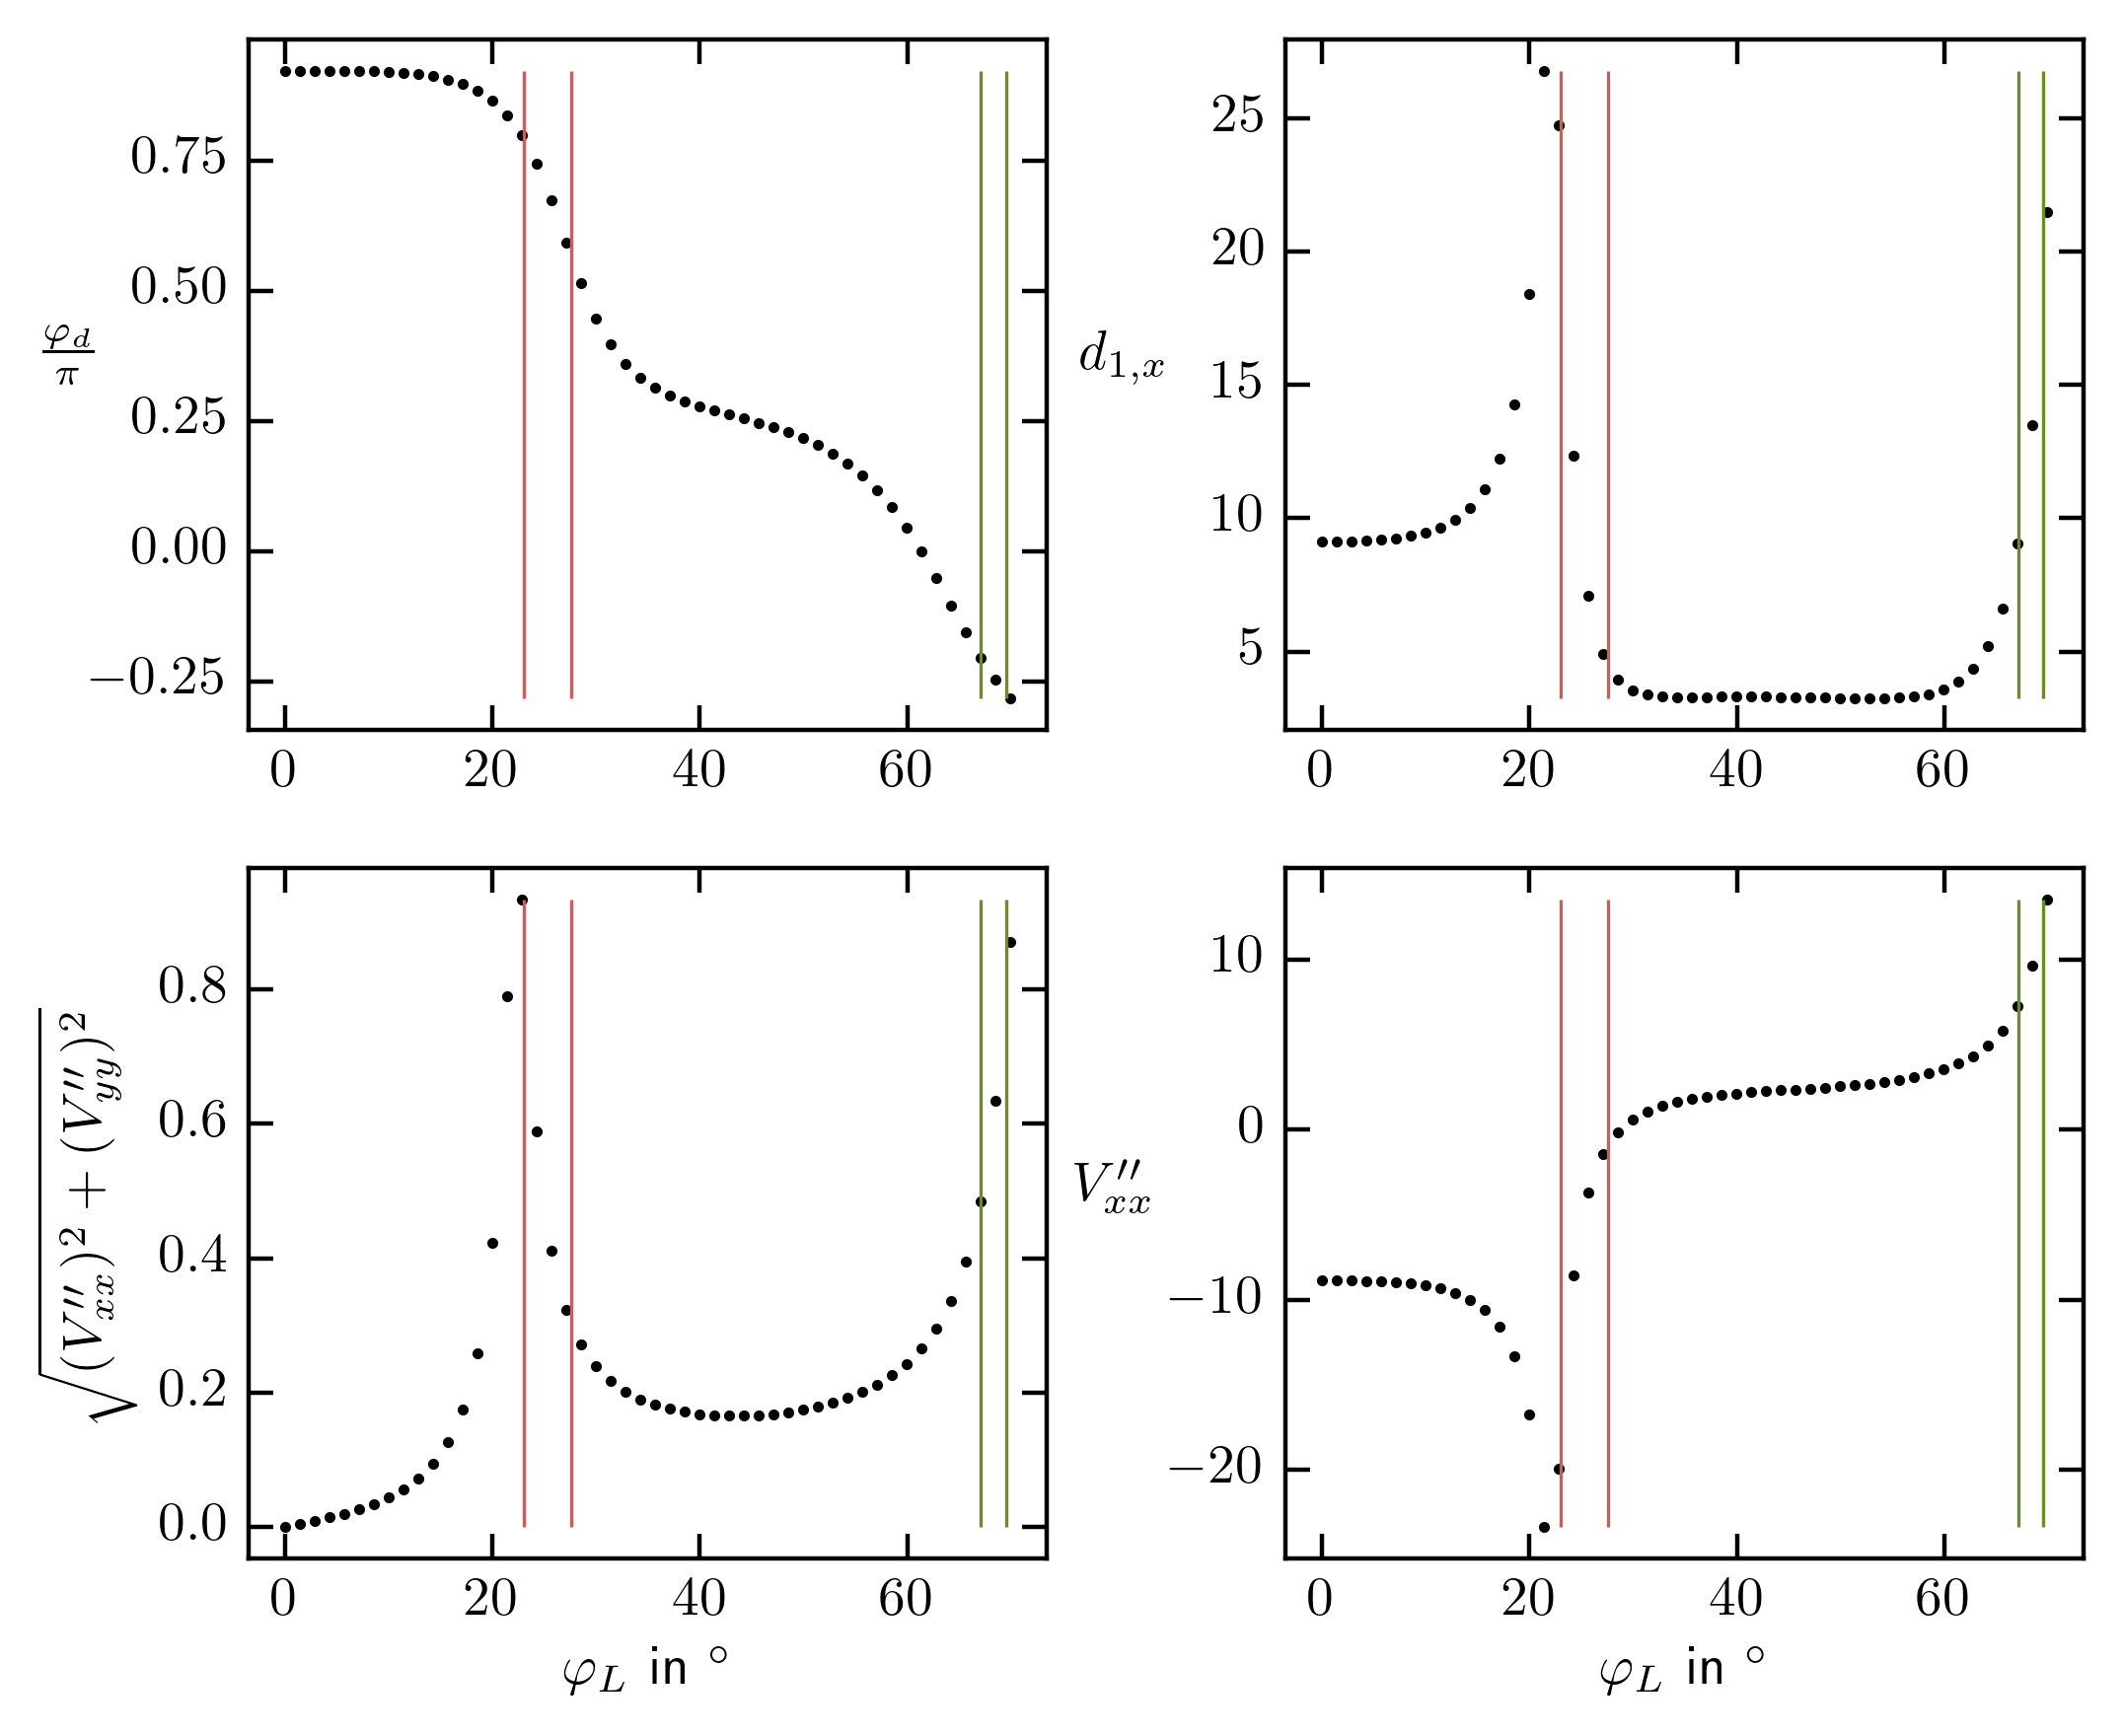

In [6]:

def d_1(a,e):
    d = 0.9
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    A = 12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9)
    B = 15*(a*e/r1**7-e/r2**7)
    res =  B**2*(1-d**2)/(A**2*d**2+B**2*(1-d**2))
    return np.array([np.sqrt(res),np.where(A*B>=0,1,-1)*np.sqrt(1-res)])

def interaction_rotated(DelR,i,j,interaction_radius,d1):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    d2 =0.9
    # if r ==0:
    #     return 0
    # if r>interaction_radius+0.01:
    #     return 0
    # Am, Bm, trash = d_1(DelR[0],DelR[1])

    # if Am*Bm==0:
    #     sign =1 
    # else:
    #     sign = np.sign(Am*Bm)
    # sign = np.where(Am*Bm>=0,1,-1)
    if i==j:
        B = -3/r**5+15*DelR[i]**2/r**7
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        return A*d1[0]*d2 - B*d1[1]*np.sqrt(1-d2**2)
    else:
        A = 12/r**5-7*15*DelR[0]**2*DelR[1]**2/r**9
        B = 15 *DelR[0]*DelR[1]/r**7
        return d1[0]*d2*A-B*d1[1]*np.sqrt(1-d2**2)

def max_phi(r):
    return np.min(np.column_stack((np.arccos((np.sqrt(1+2*r**2)-1)/2/r)/np.pi*180,np.arccos((r-1)/r)/np.pi*180)),axis=1)

linewidth = 0.6
x = np.linspace(0.08,0.12)
# phi = np.linspace(0,np.pi/2)/np.pi*180
# phi = np.linspace(25.627,25.634,30)
phi = np.linspace(0,max_phi(0.9)[0])#/180*np.pi
# alphas = np.linspace(0.9,1.3,4)
# alphas = [0.9,1,1.03,2.646]
alphas = [0.9]
# alphas = [2.646]
d = 0.9

er = np.zeros((2,len(phi)))
er[0,:] = np.cos(phi/180*np.pi)
er[1,:] = np.sin(phi/180*np.pi)
tickp = TickProperties(SZX=False,SZY=False,\
                       xtick_step_major=20,\
                        xtick_step_minor=5,\
                            ytick_step_major=10,\
                                ytick_step_minor=5)
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',tickp=tickp)
setup.fig_height = 5
setup.fig_width =6

for i in range(len(alphas)):
    fig2, ax2 = setup.return_fig(shape=(2,2),set_ticks=False)
    print(alphas[i])
    d1 = d_1(alphas[i]*np.cos(phi/180*np.pi),alphas[i]*np.sin(phi/180*np.pi))
    yy = interaction_rotated(alphas[i]*er,1,1,100,d1)
    xx = interaction_rotated(alphas[i]*er,0,0,100,d1)
    ec = np.array([-1*np.ones(len(phi)),alphas[i]*np.sin(phi/180*np.pi)])
    xy1 = interaction_rotated(alphas[i]*er,1,0,100,d1)
    xy2 = interaction_rotated(ec,1,0,100,d1)

    plots = [(np.arctan(yy/xx)+np.sign(yy)*np.pi*(1-np.sign(xx))/2)/np.pi, np.sqrt(xx**2+yy**2), d_1(alphas[i]*np.cos(phi/180*np.pi),alphas[i]*np.sin(phi/180*np.pi))[0], xx]

    start1 = 23.02
    stop1 = 27.55
    start2 = 67.07
    stop2 = 69.5

    for j in range(4):
        ax2[j//2,j%2].scatter(phi,plots[j],color='0')
        ax2[j//2,j%2].vlines(start1,min(plots[j]),max(plots[j]),color="indianred",linewidth=linewidth)
        ax2[j//2,j%2].vlines(stop1,min(plots[j]),max(plots[j]),color="indianred",linewidth=linewidth)
        ax2[j//2,j%2].vlines(start2,min(plots[j]),max(plots[j]),color="olivedrab",linewidth=linewidth)
        ax2[j//2,j%2].vlines(stop2,min(plots[j]),max(plots[j]),color="olivedrab",linewidth=linewidth)
  
    # ax2[0,0].hlines(0,phi[0],phi[-1],color='0',linewidth=linewidth)
    # varphi = np.arctan(yy/xx)+np.sign(yy)*np.pi*(1-np.sign(xx))/2
    # ax2[0,0].vlines(45.5,min(varphi)/np.pi,max(varphi)/np.pi,color='0',linewidth=linewidth)
    # ax2[0,0].vlines(23.02,min(varphi)/np.pi,max(varphi)/np.pi,color="indianred",linewidth=linewidth)
    # ax2[0,0].vlines(27.55,min(varphi)/np.pi,max(varphi)/np.pi,color="indianred",linewidth=linewidth)
    # start1 = 23.02
    # stop1 = 27.55
    # start2 = 67.07
    # stop2 = 69.5
    # d_sq = np.sqrt(xx**2+yy**2)
    # ax2[1,0].vlines(67.07,min(d_sq),max(d_sq),color="indianred",linewidth=linewidth)
    # ax2[1,0].vlines(69.5,min(d_sq),max(d_sq),color="indianred",linewidth=linewidth)

    # ax2[0,1].vlines(54,min(xx),max(xx),color="indianred",linewidth=linewidth)
    # ax2[0,1].vlines(56.7,min(xx),max(xx),color="indianred",linewidth=linewidth)

    # ax2[1,1].vlines(54,min(yy),max(yy),color="indianred",linewidth=linewidth)
    # ax2[1,1].vlines(56.7,min(yy),max(yy),color="indianred",linewidth=linewidth)

    # ax2[1,1].scatter(phi,xx)
    # # ax2[1,1].hlines(0,phi[0],phi[-1],color='0',linewidth=linewidth)
    # # ax2[1,1].vlines(45.5,min(yy),max(yy),color='0',linewidth=linewidth)
    # # ax2[1,1].scatter(phi,yy)

    ax2[1,0].set_xlabel(r'$\varphi_L$ in $^\circ$')
    ax2[1,1].set_xlabel(r'$\varphi_L$ in $^\circ$')
    ax2[1,0].set_ylabel(r"$\sqrt{(V''_{xx})^2+(V''_{yy})^2}$")
    ax2[1,1].set_ylabel(r"$V''_{xx}$",rotation=0,labelpad=10)
    ax2[0,0].set_ylabel(r"$\frac{\varphi_d}{\pi}$",rotation=0)
    ax2[0,1].set_ylabel(r"$d_{1,x}$",rotation=0,labelpad=16)


 
    plt.subplots_adjust(wspace=0.3)
    # plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"dipole_orientation_off_plane.pdf",bbox_inches='tight')
    plt.show()

plt.show()

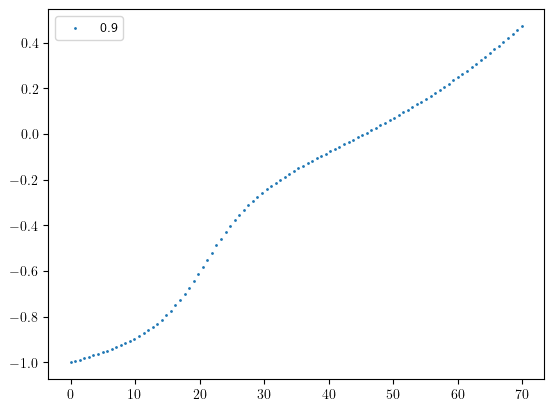

In [9]:



def phi_1(a,e):
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    B = (12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9))*(-1)
    A = 45*(a*e/r1**7-e/r2**7)-7*15*(a**3*e/r1**9-e/r2**9)
    res =  np.arctan(A/B)+np.where(B>=0,1,-1)*np.pi*(1-np.where(B>=0,1,-1))/2
    return res#, -B*np.sin(res)+A*np.cos(res)

def interaction_dipplain(DelR,i,j,cut,d):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    # if r ==0:
    #     return 0
    # if r>cut+0.01:
    #     return 0
 
    
    if i==j:
        A = -3/r**5+15*(DelR[0]**2+DelR[i]*DelR[0]*2+ DelR[i]**2)/r**7-7*15*DelR[0]**2*DelR[i]**2/r**9
        B = 15*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        if i==0:
            A += 15*2*DelR[0]**2/r**7-6/r**5
            B += 30*DelR[0]*DelR[1]/r**7
        return A*d[0] + B*d[1]
    else:
        B = 12/r**5-7*15*DelR[0]**2*DelR[1]**2/r**9
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]**3*DelR[1]/r**9
        return A*d[0] + B*d[1]

# plot the above with axis scaled in units of pi

fig, ax = plt.subplots(1,1)
# fig2, ax2 = plt.subplots(1,1)
# fig3, ax3 = plt.subplots(1,1)
# r = np.linspace(0.9,1.3,4)
r = [0.9]
phi = np.linspace(0,max_phi(0.9)[0],100)/180*np.pi
r1 = np.zeros((2,len(phi)))
r2 = np.zeros_like(r1)
d1 = d_plane(r[0]*np.cos(phi),r[0]*np.sin(phi))

for i in range(len(r)):  
    r1[0,:] = np.cos(phi)*r[i]
    r1[1,:] = np.sin(phi)*r[i]
    r2[0,:] = -1
    r2[1,:] = np.sin(phi)*r[i]       
    ax.scatter(phi/np.pi*180,phi_1(r[i]*np.cos(phi),r[i]*np.sin(phi))/np.pi,label=f"{r[i]}")
    # ax2.scatter(phi/np.pi*180,phi_1(r[i]*np.cos(phi),r[i]*np.sin(phi))[1],label=f"{r[i]}")
    # ax3.scatter(phi/np.pi,interaction_dipplain(r1,1,0,100)+interaction_dipplain(r2,1,0,100),label=f"{r[i]}")
ax.legend()
plt.show()


0.9
(50,)


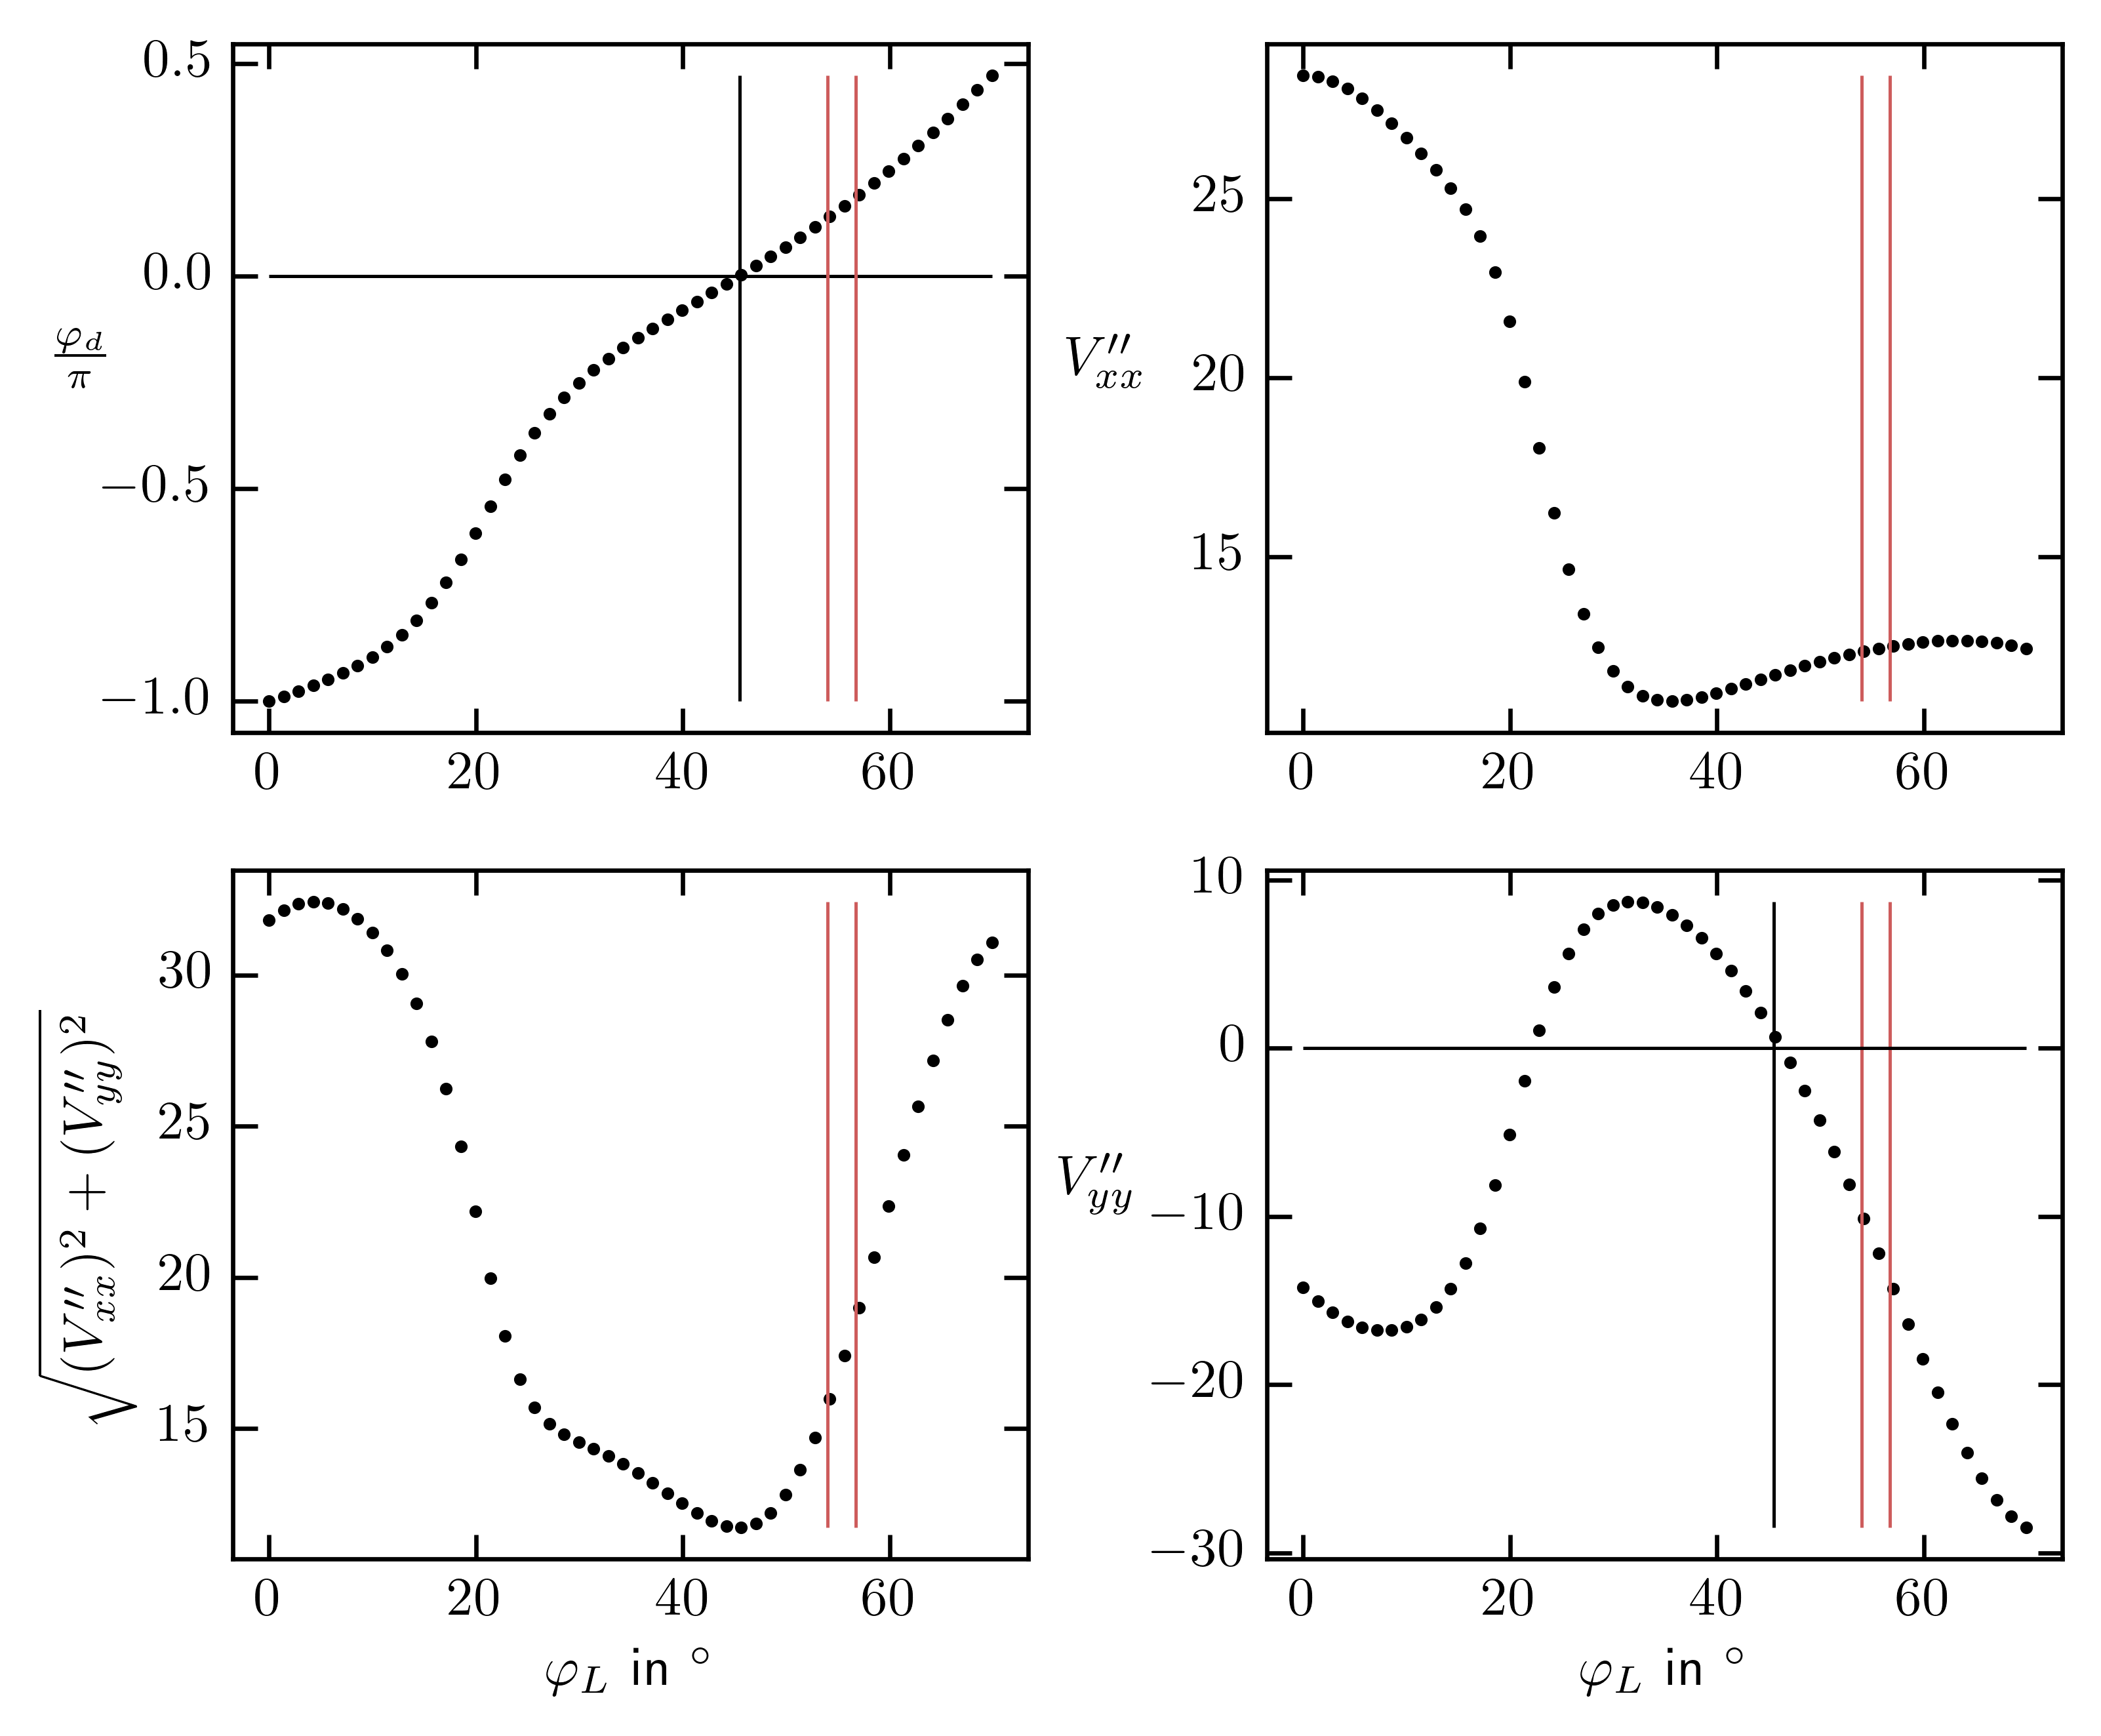

In [10]:

x = np.linspace(0.08,0.12)
# phi = np.linspace(0,np.pi/2)/np.pi*180
# phi = np.linspace(45,46,30)
linewidth = 0.6
phi = np.linspace(0,max_phi(0.9)[0])#/180*np.pi
plt.rcParams["axes.unicode_minus"]=True
plt.rcParams["font.size"]=10
plt.rcParams["text.usetex"]=True
plt.rcParams["font.serif"]="Computer Modern Serif"
# alphas = np.linspace(0.9,1.3,4)
# alphas = [0.9,1,1.03,2.646]
alphas = [0.9]
# alphas = [2.646]
d = 0.9
def d_plane(a,e):
    d = 0.7 
    phi = phi_1(a,e)
    return d*np.array([np.cos(phi),np.sin(phi)])
interaction = interaction_dipplain
er = np.zeros((2,len(phi)))
er[0,:] = np.cos(phi/180*np.pi)
er[1,:] = np.sin(phi/180*np.pi)


# tickformat = Format(xscale=d,yscale=k,xprec="{:.1f}",yprec="{:.1f}")
# plots = [stab_xsol,stab_ysol,stab_zsol]
tickp = TickProperties(SZX=False,SZY=False,\
                       xtick_step_major=20,\
                        xtick_step_minor=5,\
                            ytick_step_major=10,\
                                ytick_step_minor=5)
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',tickp=tickp)
setup.fig_height = 5
setup.fig_width =6
for i in range(len(alphas)):
    # fig2, ax2 = plt.subplots(2,2)
    fig2, ax2 = setup.return_fig(shape=(2,2),dots_per_inch=600,set_ticks=False)
    print(alphas[i])
    plt.rcParams["lines.markersize"]=1.3
    d1 = d_plane(alphas[i]*np.cos(phi/180*np.pi),alphas[i]*np.sin(phi/180*np.pi))
    yy = interaction(alphas[i]*er,1,1,100,d1)
    xx = interaction(alphas[i]*er,0,0,100,d1)
    ec = np.array([-1*np.ones(len(phi)),alphas[i]*np.sin(phi/180*np.pi)])
    xy1 = interaction(alphas[i]*er,1,0,100,d1)
    xy2 = interaction(ec,1,0,100,d1)
    print(xx.shape)
    ax2[1,0].scatter(phi,np.sqrt(xx**2+yy**2),label=f"{alphas[i]}",color='0')
    # ax2[1,0].scatter(phi,xy1+xy2)
    # ax2[0,0].scatter(phi,np.max(np.column_stack((np.sqrt(alphas[i]**2*np.cos(phi/180*np.pi)**2+alphas[i]**2*np.sin(phi/180*np.pi)**2),np.sqrt(1+alphas[i]**2*np.sin(phi/180*np.pi)**2))),axis=1))
    ax2[0,0].scatter(phi,phi_1(alphas[i]*np.cos(phi/180*np.pi),alphas[i]*np.sin(phi/180*np.pi))/np.pi,color='0')
    ax2[0,0].hlines(0,phi[0],phi[-1],color='0',linewidth=linewidth)
    varphi = phi_1(alphas[i]*np.cos(phi/180*np.pi),alphas[i]*np.sin(phi/180*np.pi))
    ax2[0,0].vlines(45.5,min(varphi)/np.pi,max(varphi)/np.pi,color='0',linewidth=linewidth)
    ax2[0,0].vlines(54,min(varphi)/np.pi,max(varphi)/np.pi,color="indianred",linewidth=linewidth)
    ax2[0,0].vlines(56.7,min(varphi)/np.pi,max(varphi)/np.pi,color="indianred",linewidth=linewidth)

    d_sq = np.sqrt(xx**2+yy**2)
    ax2[1,0].vlines(54,min(d_sq),max(d_sq),color="indianred",linewidth=linewidth)
    ax2[1,0].vlines(56.7,min(d_sq),max(d_sq),color="indianred",linewidth=linewidth)

    ax2[0,1].vlines(54,min(xx),max(xx),color="indianred",linewidth=linewidth)
    ax2[0,1].vlines(56.7,min(xx),max(xx),color="indianred",linewidth=linewidth)

    ax2[1,1].vlines(54,min(yy),max(yy),color="indianred",linewidth=linewidth)
    ax2[1,1].vlines(56.7,min(yy),max(yy),color="indianred",linewidth=linewidth)

    ax2[0,1].scatter(phi,xx,color='0')
    ax2[1,1].hlines(0,phi[0],phi[-1],color='0',linewidth=linewidth)
    ax2[1,1].vlines(45.5,min(yy),max(yy),color='0',linewidth=linewidth)
    ax2[1,1].scatter(phi,yy,color='0')

    ax2[1,0].set_xlabel(r'$\varphi_L$ in $^\circ$')
    ax2[1,1].set_xlabel(r'$\varphi_L$ in $^\circ$')
    ax2[1,0].set_ylabel(r"$\sqrt{(V''_{xx})^2+(V''_{yy})^2}$")
    ax2[1,1].set_ylabel(r"$V''_{yy}$",rotation=0,labelpad=10)
    ax2[0,0].set_ylabel(r"$\frac{\varphi_d}{\pi}$",rotation=0)
    ax2[0,1].set_ylabel(r"$V''_{xx}$",rotation=0,labelpad=16)


    # ax2.scatter(phi,interaction_rotated(alphas[i]*er,0,0,d,100),label=f"{alphas[i]}")
    # ax.scatter(phi,xx,label=f"{alphas[i]}")
    # ax2.scatter(phi,yy,label=f"{alphas[i]}")
    # ax.scatter(x,vxx(alphas[i]*np.cos(phi),alphas[i]*np.sin(phi),d)[1],label=f"{alphas[i]}")
    # ax2.scatter(phi,vyy(alphas[i]*np.cos(phi),alphas[i]*np.sin(phi),d)[1],label=f"{alphas[i]}")
    # ax2[i//2,i%2].legend()
    # ax2[0,1].scatter(phi,d_1(alphas[i]*np.cos(phi/180*np.pi),alphas[i]*np.sin(phi/180*np.pi))[0])
    # if i==3:
    #     for j in range(4):
    #         # ax2[0,1].vlines(41.5,np.min(d_1(alphas[i]*np.sin(phi/180*np.pi),alphas[i]*np.cos(phi/180*np.pi),d)[2]),np.max(d_1(alphas[i]*np.sin(phi/180*np.pi),alphas[i]*np.cos(phi/180*np.pi),d)[2]))
    #         ax2[j//2,j%2].vlines(41.5,0,0.1,color='0')
    # ax2[1,1].scatter(phi,i*3+vyy(alphas[i]*np.sin(phi/180*np.pi),alphas[i]*np.cos(phi/180*np.pi),d)[0],label=f"{alphas[i]}")
    # ax2[1,1].scatter(phi,np.where(Am*Bm>=0,1,-1))
    plt.subplots_adjust(wspace=0.3)
    # plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"dipole_orientation_in_plain.pdf",bbox_inches='tight')
    plt.show()
# ax.legend()
# ax2.legend()
# ax3.hlines(0,phi[0],phi[-1])
# ax3.legend()
# ax4.legend()
plt.show()

0.9
(50,)


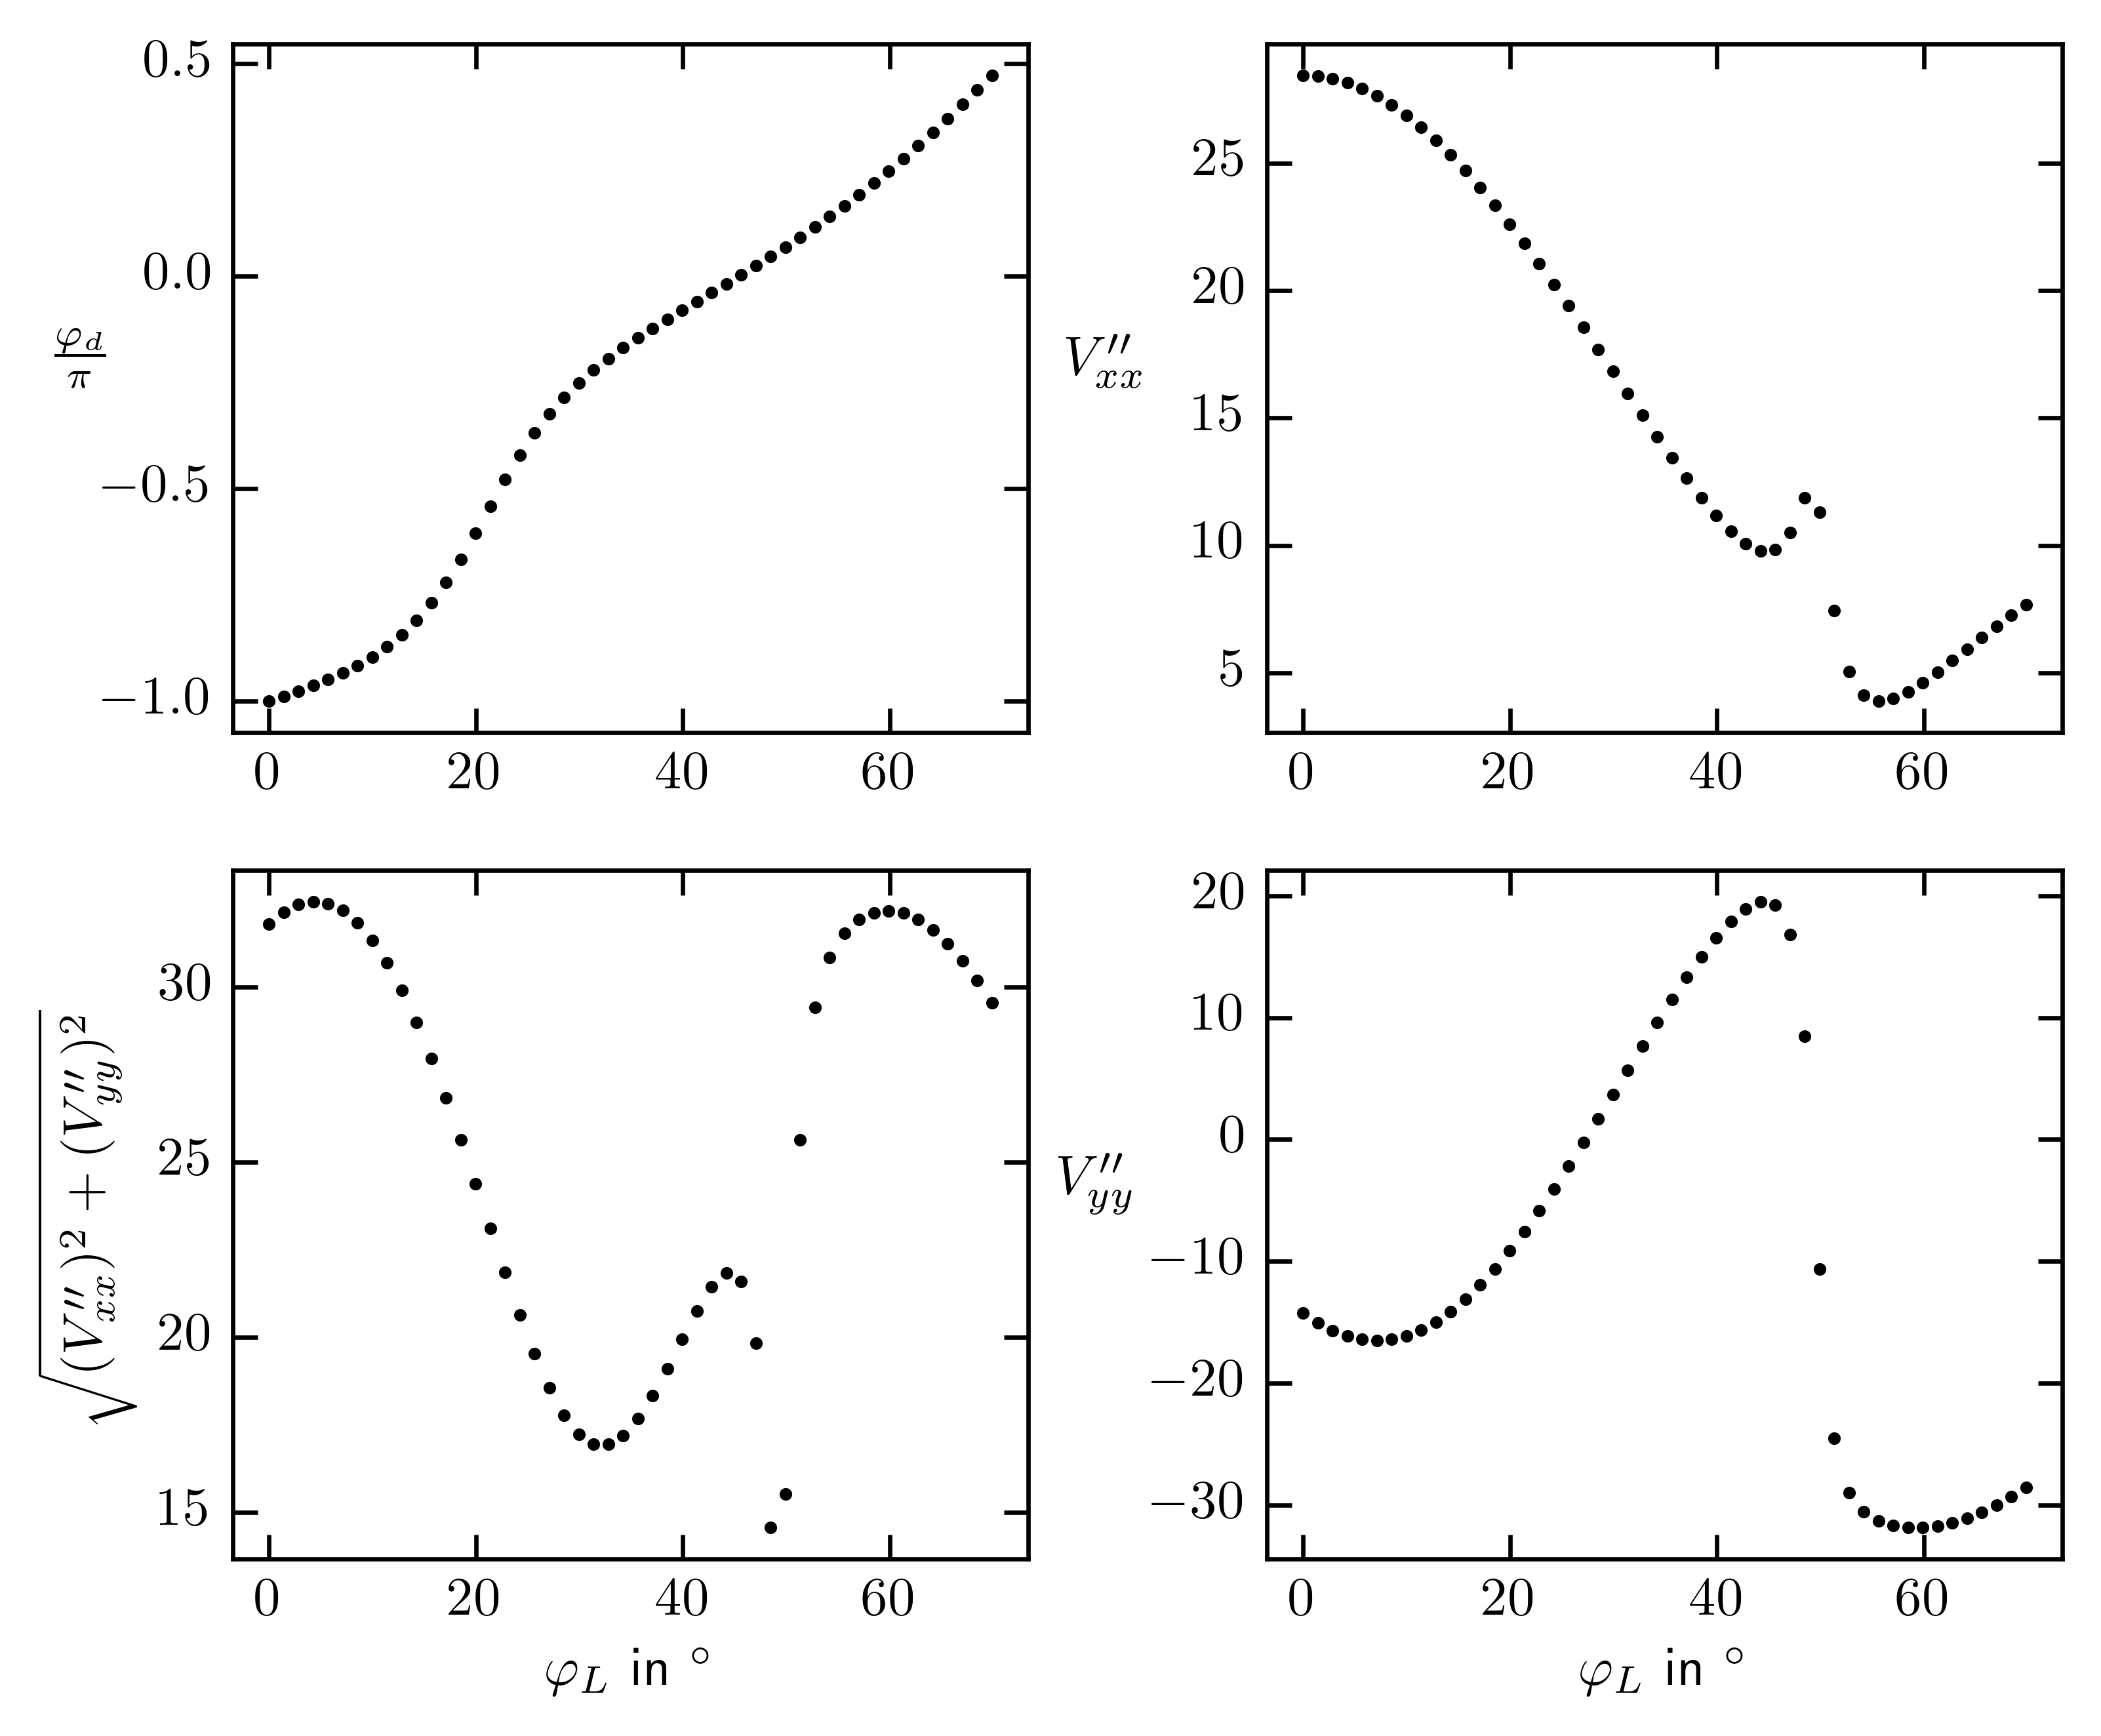

In [11]:
def phi_2(r,phi):
    B  = (-1)*(24/r**5-7*15*np.cos(phi)**2*np.sin(phi)**2/r**5)
    A = 45*np.cos(phi)*np.sin(phi)/r**5-7*15*np.cos(phi)**3*np.sin(phi)/r**5
    res =  np.arctan(A/B)+np.where(B>=0,1,-1)*np.pi*(1-np.where(B>=0,1,-1))/2
    return res


def d_plane2(r,phi):
    d = 0.7 
    phi = phi_2(r,phi)
    return d*np.array([np.cos(phi),np.sin(phi)])
interaction = interaction_dipplain
er = np.zeros((2,len(phi)))
er[0,:] = np.cos(phi/180*np.pi)
er[1,:] = np.sin(phi/180*np.pi)

# phi = np.linspace(45,55,)
# tickformat = Format(xscale=d,yscale=k,xprec="{:.1f}",yprec="{:.1f}")
# plots = [stab_xsol,stab_ysol,stab_zsol]
tickp = TickProperties(SZX=False,SZY=False,\
                       xtick_step_major=20,\
                        xtick_step_minor=5,\
                            ytick_step_major=10,\
                                ytick_step_minor=5)
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',tickp=tickp)
setup.fig_height = 5
setup.fig_width =6
for i in range(len(alphas)):
    # fig2, ax2 = plt.subplots(2,2)
    fig2, ax2 = setup.return_fig(shape=(2,2),dots_per_inch=600,set_ticks=False)
    print(alphas[i])
    plt.rcParams["lines.markersize"]=1.3
    d1 = d_plane2(alphas[i],phi/180*np.pi)
    yy = interaction(alphas[i]*er,1,1,100,d1)
    xx = interaction(alphas[i]*er,0,0,100,d1)
    ec = np.array([-1*np.ones(len(phi)),np.zeros(len(phi))])*alphas[i]
    xy1 = interaction(alphas[i]*er,1,0,100,d1)
    xy2 = interaction(ec,1,0,100,d1)
    print(xx.shape)
    ax2[1,0].scatter(phi,np.sqrt(xx**2+yy**2),label=f"{alphas[i]}",color='0')
    # ax2[1,0].scatter(phi,xy1+xy2)
    # ax2[0,0].scatter(phi,np.max(np.column_stack((np.sqrt(alphas[i]**2*np.cos(phi/180*np.pi)**2+alphas[i]**2*np.sin(phi/180*np.pi)**2),np.sqrt(1+alphas[i]**2*np.sin(phi/180*np.pi)**2))),axis=1))
    ax2[0,0].scatter(phi,phi_1(alphas[i]*np.cos(phi/180*np.pi),alphas[i]*np.sin(phi/180*np.pi))/np.pi,color='0')
    # ax2[0,0].hlines(0,phi[0],phi[-1],color='0',linewidth=linewidth)
    varphi = phi_1(alphas[i]*np.cos(phi/180*np.pi),alphas[i]*np.sin(phi/180*np.pi))
    # ax2[0,0].vlines(45.5,min(varphi)/np.pi,max(varphi)/np.pi,color='0',linewidth=linewidth)
    # ax2[0,0].vlines(54,min(varphi)/np.pi,max(varphi)/np.pi,color="indianred",linewidth=linewidth)
    # ax2[0,0].vlines(56.7,min(varphi)/np.pi,max(varphi)/np.pi,color="indianred",linewidth=linewidth)

    d_sq = np.sqrt(xx**2+yy**2)
    # ax2[1,0].vlines(54,min(d_sq),max(d_sq),color="indianred",linewidth=linewidth)
    # ax2[1,0].vlines(56.7,min(d_sq),max(d_sq),color="indianred",linewidth=linewidth)

    # ax2[0,1].vlines(54,min(xx),max(xx),color="indianred",linewidth=linewidth)
    # ax2[0,1].vlines(56.7,min(xx),max(xx),color="indianred",linewidth=linewidth)

    # ax2[1,1].vlines(54,min(yy),max(yy),color="indianred",linewidth=linewidth)
    # ax2[1,1].vlines(56.7,min(yy),max(yy),color="indianred",linewidth=linewidth)

    ax2[0,1].scatter(phi,xx,color='0')
    # ax2[1,1].hlines(0,phi[0],phi[-1],color='0',linewidth=linewidth)
    # ax2[1,1].vlines(45.5,min(yy),max(yy),color='0',linewidth=linewidth)
    ax2[1,1].scatter(phi,yy,color='0')

    ax2[1,0].set_xlabel(r'$\varphi_L$ in $^\circ$')
    ax2[1,1].set_xlabel(r'$\varphi_L$ in $^\circ$')
    ax2[1,0].set_ylabel(r"$\sqrt{(V''_{xx})^2+(V''_{yy})^2}$")
    ax2[1,1].set_ylabel(r"$V''_{yy}$",rotation=0,labelpad=10)
    ax2[0,0].set_ylabel(r"$\frac{\varphi_d}{\pi}$",rotation=0)
    ax2[0,1].set_ylabel(r"$V''_{xx}$",rotation=0,labelpad=16)


    # ax2.scatter(phi,interaction_rotated(alphas[i]*er,0,0,d,100),label=f"{alphas[i]}")
    # ax.scatter(phi,xx,label=f"{alphas[i]}")
    # ax2.scatter(phi,yy,label=f"{alphas[i]}")
    # ax.scatter(x,vxx(alphas[i]*np.cos(phi),alphas[i]*np.sin(phi),d)[1],label=f"{alphas[i]}")
    # ax2.scatter(phi,vyy(alphas[i]*np.cos(phi),alphas[i]*np.sin(phi),d)[1],label=f"{alphas[i]}")
    # ax2[i//2,i%2].legend()
    # ax2[0,1].scatter(phi,d_1(alphas[i]*np.cos(phi/180*np.pi),alphas[i]*np.sin(phi/180*np.pi))[0])
    # if i==3:
    #     for j in range(4):
    #         # ax2[0,1].vlines(41.5,np.min(d_1(alphas[i]*np.sin(phi/180*np.pi),alphas[i]*np.cos(phi/180*np.pi),d)[2]),np.max(d_1(alphas[i]*np.sin(phi/180*np.pi),alphas[i]*np.cos(phi/180*np.pi),d)[2]))
    #         ax2[j//2,j%2].vlines(41.5,0,0.1,color='0')
    # ax2[1,1].scatter(phi,i*3+vyy(alphas[i]*np.sin(phi/180*np.pi),alphas[i]*np.cos(phi/180*np.pi),d)[0],label=f"{alphas[i]}")
    # ax2[1,1].scatter(phi,np.where(Am*Bm>=0,1,-1))
    plt.subplots_adjust(wspace=0.3)
    # plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"dipole_orientation_in_plane_hex1D.pdf",bbox_inches='tight')
    plt.show()
# ax.legend()
# ax2.legend()
# ax3.hlines(0,phi[0],phi[-1])
# ax3.legend()
# ax4.legend()
plt.show()

0.3


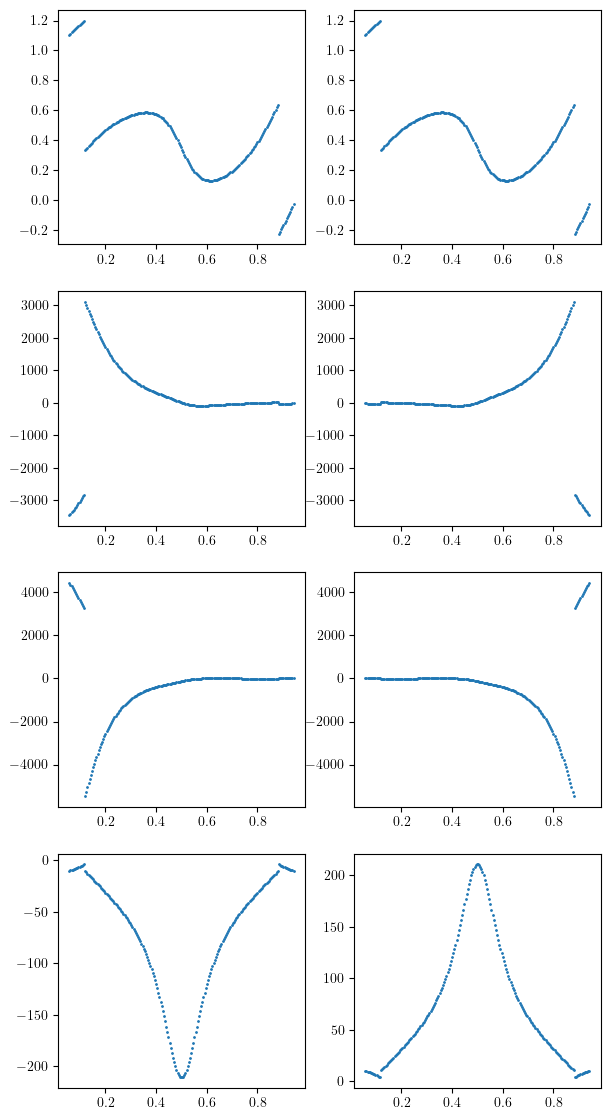

In [3]:
def Vxy_decomp(x,y):
    r = np.sqrt(x**2+y**2)
    A = 24/r**5-7*30*x**2*y**2/r**9
    C = 45*x*y/r**7
    B = -7*15*x**3*y/r**9
    D = -7*15*x*y**3/r**9
    return np.array([A, B, C, D])

def Vxy(DelR,d):
    A, B, C, D = Vxy_decomp(DelR[0],DelR[1])
    return A*d[0]*d[1]+C+B*d[0]**2+D*d[1]**2

def Vaa(DelR,i,d):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    A = -3/r**5+15*(DelR[0]**2*d[0]**2+DelR[1]**2*d[1]**2+2*DelR[0]*DelR[1]*d[0]*d[1])/r**7
    B = -6*d[i]**2/r**5+30*(2*d[i]*DelR[i]*(DelR[0]*d[0]+DelR[1]*d[1]))/r**7
    C = 15*(DelR[i]**2/r**7-7*DelR[i]**2*(DelR[0]**2*d[0]**2+DelR[1]**2*d[1]**2+2*DelR[0]*DelR[1]*d[0]*d[1])/r**9)
    return A+B+C

def interaction_aligned_dip(DelR,i,j,interaction_cut,d):
    if i==j:
        return Vaa(DelR,i,d)
    else:
        return Vxy(DelR,d)


def d_aligned(b,h,a):
    A, B, C, D = Vxy_decomp(b,h)+Vxy_decomp(b-a,h)
    a = (D-B)**2+A**2
    bi = -(A**2+2*(C+D)*(D-B))
    c = (C+D)**2
    sq = np.sqrt(bi**2-4*a*c)
    ot = -bi
    dx = np.sqrt((ot+sq)/2/a)
    sign = np.where((-(C+D)+(D-B)*dx**2)*A>=0,1,-1)
    return np.array([dx,np.sqrt(1-dx**2)*sign])
    # return A, B, C, D
    # return ot+sq, ot-sq
def max_b(h,a):
    return np.sqrt((a-0.011)**2-h**2)
a = 1
h = np.linspace(0.3,0.1)
b = np.linspace(0.2,0.8,4)
b1 = b[:100]
b2 = b[100:][::-1]
ind = 1

# for i in range(len(h)):
for i in range(1):
    print(h[i])
    b = np.linspace(a-max_b(h[i],a),max_b(h[i],a),200)
    r1 = np.array([b,h[i]*np.ones(len(b))])
    r2 = np.array([b-a,h[i]*np.ones(len(b))])
    phi = np.arctan(h[i]/b)#/np.pi*2
    fig, ax = plt.subplots(4,2,figsize=(7,14))
    d = d_aligned(r1[0],r1[1],a)
    phi_d = np.arctan(d[1]/d[0])
    # for j in range(len(phi)):
    #     fig, ax = plt.subplots(1,1)
    #     ax.plot([0,d[0,j]],[0,d[1,j]])
    #     ax.plot([0,b[j]],[0,h[i]])
    r = [r1,r2]
    for j in range(2):
        xy = interaction_aligned_dip(r[j],0,1,100,d)
        xx = interaction_aligned_dip(r[j],0,0,100,d)
        yy = interaction_aligned_dip(r[j],1,1,100,d)
        # ax.scatter(b,xy1)
        ax[0,j].scatter(b,(phi-phi_d)/np.pi*2)
        ax[1,j].scatter(b,xx)
        ax[2,j].scatter(b,yy)
        ax[3,j].scatter(b,xy)
    # ax.scatter(b1,prop(b1,h[i])[ind]-prop(b2,h[i])[ind],s=30,label=f"+{h[i]}")
    # ax.scatter(b,d_aligned(b,h[i])[0],s=30,label=f"x{h[i]}")
    # ax.scatter(b,d_aligned(b,h[i])[1],s=30,label=f"y{h[i]}")
    # ax.legend()
    plt.show()
# print('Hello there General KENOBI')


In [63]:
from scipy.optimize import minimize_scalar, minimize, root
def min_xy(h):
    a=1
    # print(h)
    b = np.linspace(a-max_b(h,a),max_b(h,a),20000000)
    r = np.array([b,h*np.ones(len(b))])
    d = d_aligned(r[0],r[1],a)
    xy = interaction_aligned_dip(r,0,1,100,d)
    min_interaction = np.min(np.abs(xy))
    return min_interaction

def min_xy2d(p):
    a=1
    h = p[0]
    b= p[1]
   
    
    r = np.array([b,h])
    d = d_aligned(r[0],r[1],a)
    xy = interaction_aligned_dip(r,0,1,100,d)
    min_interaction = np.min(np.abs(xy))
    return 0, min_interaction
e = 1e-5
bees = np.linspace(0.001,0.5)
hmin = np.zeros_like(bees)
minima = np.ones_like(bees)
for i in range(len(bees)):
    r = root(min_xy2d,x0=(0.3,bees[i]),method="hybr",tol=1e-18)
    ratt = r.x[0]
    if 0<ratt and ratt<1:
        hmin[i]=ratt
        minima[i] = r.fun[1]
# minimize(min_xy2d,x0=(0.09,0.1),bounds=np.array([[0.07,0.12],[0.07,0.15]]))
# r = root(min_xy2d,x0=(0.07,0.09),method="hybr",tol=1e-18)
# minimize_scalar(min_xy,bracket=(0.173,1.174),bounds=(0.08,0.1))
hmin, minima


(array([0.        , 0.        , 0.        , 0.34942602, 0.0427344 ,
        0.34400748, 0.32770522, 0.06841951, 0.238156  , 0.25102422,
        0.22300236, 0.29741474, 0.33898233, 0.25743857, 0.22603798,
        0.23511965, 0.42262933, 0.43801436, 0.4478505 , 0.45717179,
        0.46600916, 0.47438969, 0.541303  , 0.49911078, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.57303247, 0.5743553 ,
        0.57543531, 0.5762739 , 0.57687213, 0.57723077, 0.57735027]),
 array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 3.58454658e-01,
        1.74622983e-10, 6.70837619e+00, 6.17999450e+00, 1.89174898e-10,
        0.00000000e+00, 3.63797881e-12, 5.45696821e-12, 3.30874080e+00,
        7.08771115e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        5.28685960e-01, 7.9580

In [60]:
r

 message: The solution converged.
 success: True
  status: 1
     fun: [ 0.000e+00  0.000e+00]
       x: [ 5.774e-01  5.000e-01]
  method: hybr
    nfev: 15
    fjac: [[ 0.000e+00  1.000e+00]
           [ 1.000e+00  0.000e+00]]
       r: [-1.696e+02  1.113e+02  0.000e+00]
     qtf: [ 1.609e-10  0.000e+00]

(np.float64(0.41357714905097964), np.float64(0.10805553618055806))


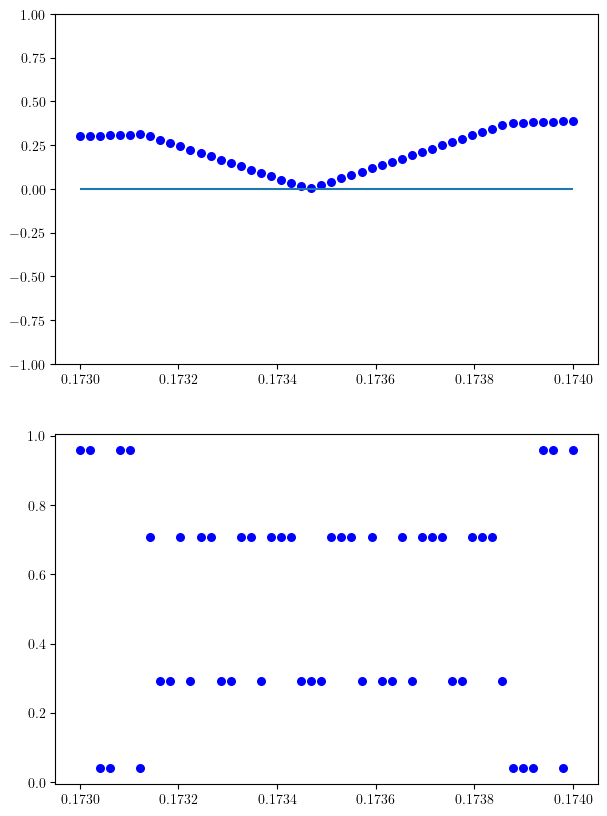

In [34]:
a = 1
h = np.linspace(0.173,0.174)

def min_xy(h,a):
    b = np.linspace(a-max_b(h,a),max_b(h,a),200)
    r = np.array([b,h*np.ones(len(b))])
    d = d_aligned(r[0],r[1],a)
    xy = interaction_aligned_dip(r,0,1,100,d)
    min_interaction = np.min(np.abs(xy))
    min_index = np.argmin(np.abs(xy))
    return min_interaction, b[min_index]

print(min_xy(0.09472646770006546,1))
fig, ax = plt.subplots(2,1,figsize=(7,10))
for i in range(len(h)):
# for i in range(1):
    # print(h[i])
    b = np.linspace(a-max_b(h[i],a),max_b(h[i],a),200)
    r1 = np.array([b,h[i]*np.ones(len(b))])
    r2 = np.array([b-a,h[i]*np.ones(len(b))])
    phi = np.arctan(h[i]/b)#/np.pi*2
    
    d = d_aligned(r1[0],r1[1],a)
    phi_d = np.arctan(d[1]/d[0])
    # for j in range(len(phi)):
    #     fig, ax = plt.subplots(1,1)
    #     ax.plot([0,d[0,j]],[0,d[1,j]])
    #     ax.plot([0,b[j]],[0,h[i]])
    r = [r1,r2]
    for j in range(1):
        xy = interaction_aligned_dip(r[j],0,1,100,d)
        xx = interaction_aligned_dip(r[j],0,0,100,d)
        yy = interaction_aligned_dip(r[j],1,1,100,d)
        # ax.scatter(b,xy1)
        min_interaction = np.min(np.abs(xy))#xx**2+yy**2)
        min_ind = np.argmin(np.abs(xy))#xx**2+yy**2)
        ax[0].scatter(h[i],min_interaction,s=30,color='blue')
        ax[1].scatter(h[i],b[min_ind],s=30,color='blue')
        # ax[2,j].scatter(b,yy)
        # ax[3,j].scatter(b,xy)
    # ax.scatter(b1,prop(b1,h[i])[ind]-prop(b2,h[i])[ind],s=30,label=f"+{h[i]}")
    # ax.scatter(b,d_aligned(b,h[i])[0],s=30,label=f"x{h[i]}")
    # ax.scatter(b,d_aligned(b,h[i])[1],s=30,label=f"y{h[i]}")
    # ax.legend()
ax[0].set_ylim(-1,1)
ax[0].hlines(0,h[0],h[-1])
plt.show()

0.2


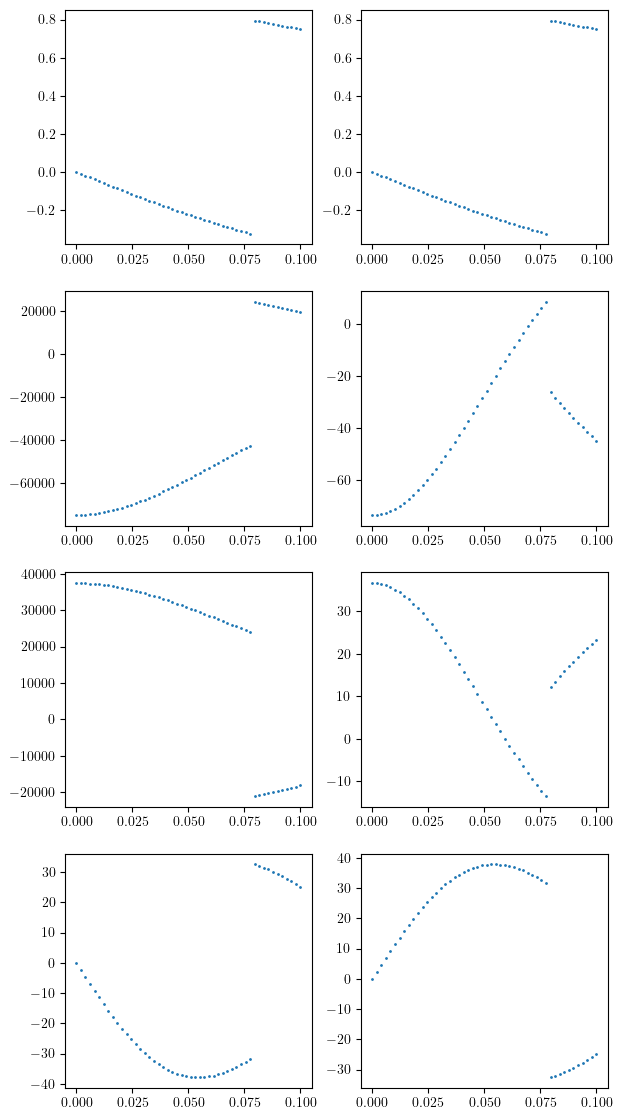

0.4


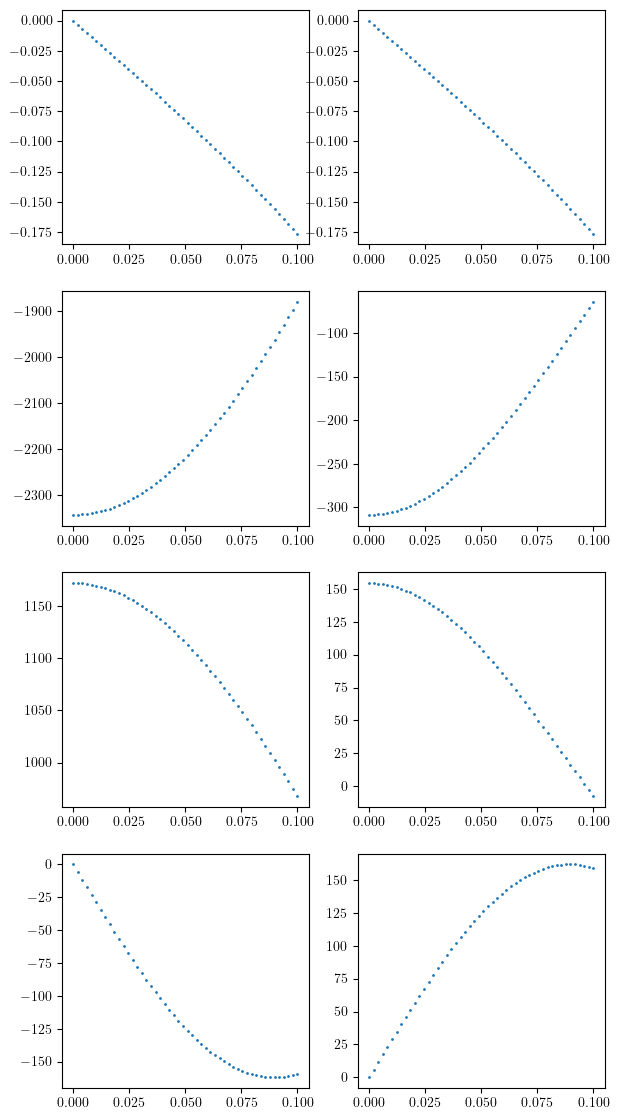

0.6000000000000001


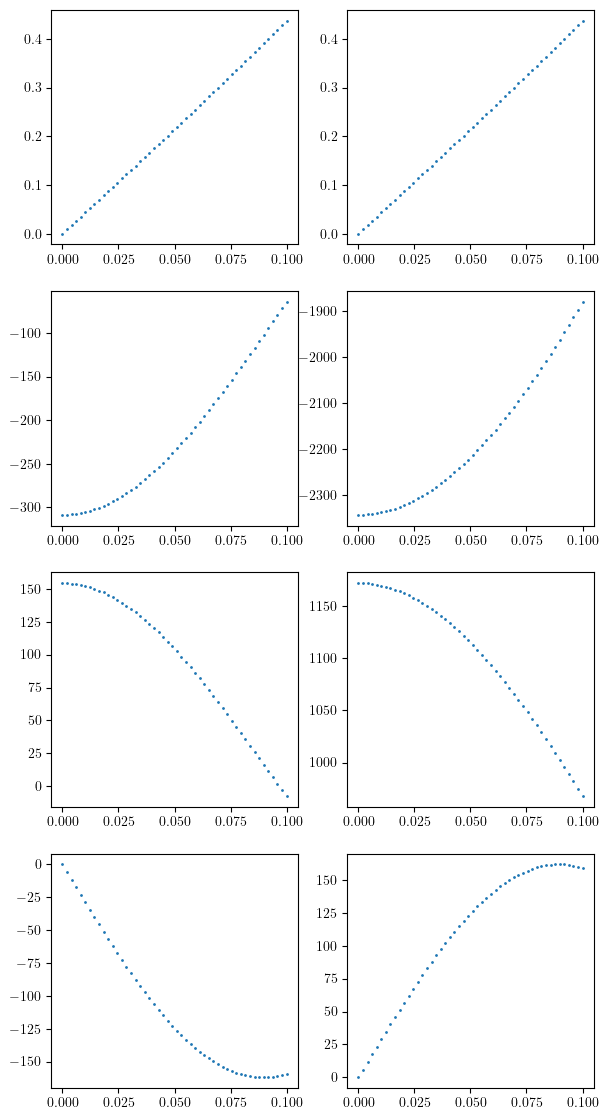

0.8


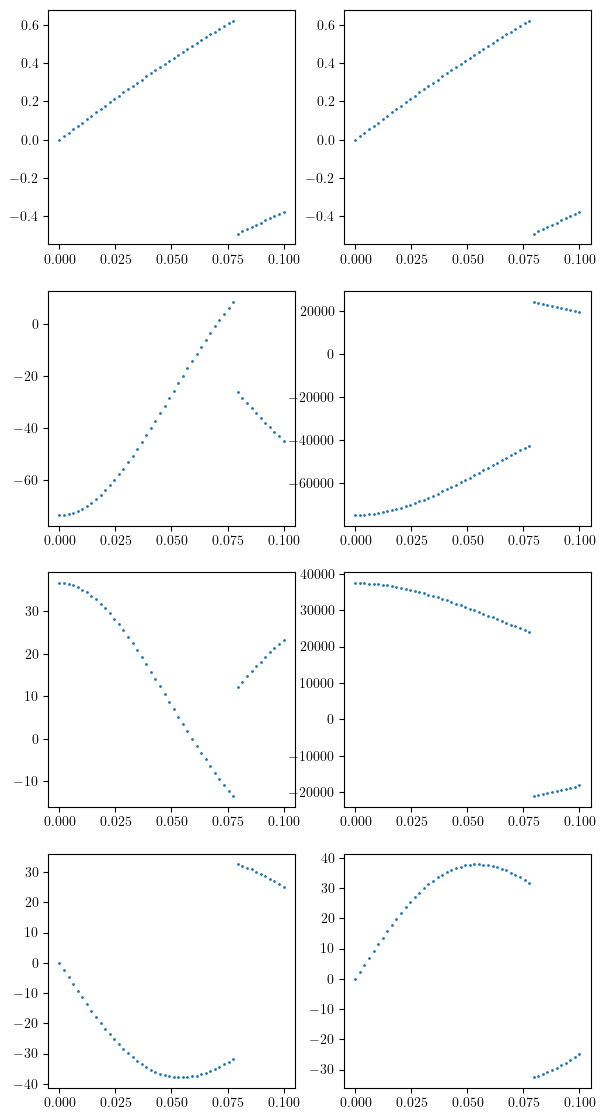

In [5]:
def Vxy_decomp(x,y):
    r = np.sqrt(x**2+y**2)
    A = 24/r**5-7*30*x**2*y**2/r**9
    C = 45*x*y/r**7
    B = -7*15*x**3*y/r**9
    D = -7*15*x*y**3/r**9
    return np.array([A, B, C, D])

def Vxy(DelR,d):
    A, B, C, D = Vxy_decomp(DelR[0],DelR[1])
    return A*d[0]*d[1]+C+B*d[0]**2+D*d[1]**2

def Vaa(DelR,i,d):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    A = -3/r**5+15*(DelR[0]**2*d[0]**2+DelR[1]**2*d[1]**2+2*DelR[0]*DelR[1]*d[0]*d[1])/r**7
    B = -6*d[i]**2/r**5+30*(2*d[i]*DelR[i]*(DelR[0]*d[0]+DelR[1]*d[1]))/r**7
    C = 15*(DelR[i]**2/r**7-7*DelR[i]**2*(DelR[0]**2*d[0]**2+DelR[1]**2*d[1]**2+2*DelR[0]*DelR[1]*d[0]*d[1])/r**9)
    return A+B+C

def interaction_aligned_dip(DelR,i,j,interaction_cut,d):
    if i==j:
        return Vaa(DelR,i,d)
    else:
        return Vxy(DelR,d)


def d_aligned(b,h,a):
    A, B, C, D = Vxy_decomp(b,h)+Vxy_decomp(b-a,h)
    a = (D-B)**2+A**2
    bi = -(A**2+2*(C+D)*(D-B))
    c = (C+D)**2
    sq = np.sqrt(bi**2-4*a*c)
    ot = -bi
    dx = np.sqrt((ot+sq)/2/a)
    sign = np.where((-(C+D)+(D-B)*dx**2)*A>=0,1,-1)
    return np.array([dx,np.sqrt(1-dx**2)*sign])
    # return A, B, C, D
    # return ot+sq, ot-sq
def max_b(h,a):
    return np.sqrt((a-0.011)**2-h**2)
a = 1
h = np.linspace(0,0.1)
b = np.linspace(0.2,0.8,4)
b1 = b[:100]
b2 = b[100:][::-1]
ind = 1

for i in range(len(b)):
# for i in range(1):
    print(b[i])
    # b = np.linspace(a-max_b(h[i],a),max_b(h[i],a),200)
    r1 = np.array([np.ones(len(h))*b[i],h])
    r2 = np.array([np.ones(len(h))*(b[i]-a),h])
    phi = np.arctan(h/b[i])#/np.pi*2
    fig, ax = plt.subplots(4,2,figsize=(7,14))
    d = d_aligned(r1[0],r1[1],a)
    phi_d = np.arctan(d[1]/d[0])
    # for j in range(len(phi)):
    #     fig, ax = plt.subplots(1,1)
    #     ax.plot([0,d[0,j]],[0,d[1,j]])
    #     ax.plot([0,b[j]],[0,h[i]])
    r = [r1,r2]
    for j in range(2):
        xy = interaction_aligned_dip(r[j],0,1,100,d)
        xx = interaction_aligned_dip(r[j],0,0,100,d)
        yy = interaction_aligned_dip(r[j],1,1,100,d)
        # ax.scatter(b,xy1)
        ax[0,j].scatter(h,(phi-phi_d)/np.pi*2)
        ax[1,j].scatter(h,xx)
        ax[2,j].scatter(h,yy)
        ax[3,j].scatter(h,xy)
    # ax.scatter(b1,prop(b1,h[i])[ind]-prop(b2,h[i])[ind],s=30,label=f"+{h[i]}")
    # ax.scatter(b,d_aligned(b,h[i])[0],s=30,label=f"x{h[i]}")
    # ax.scatter(b,d_aligned(b,h[i])[1],s=30,label=f"y{h[i]}")
    # ax.legend()
    plt.show()
# print('Hello there General KENOBI')


1.1


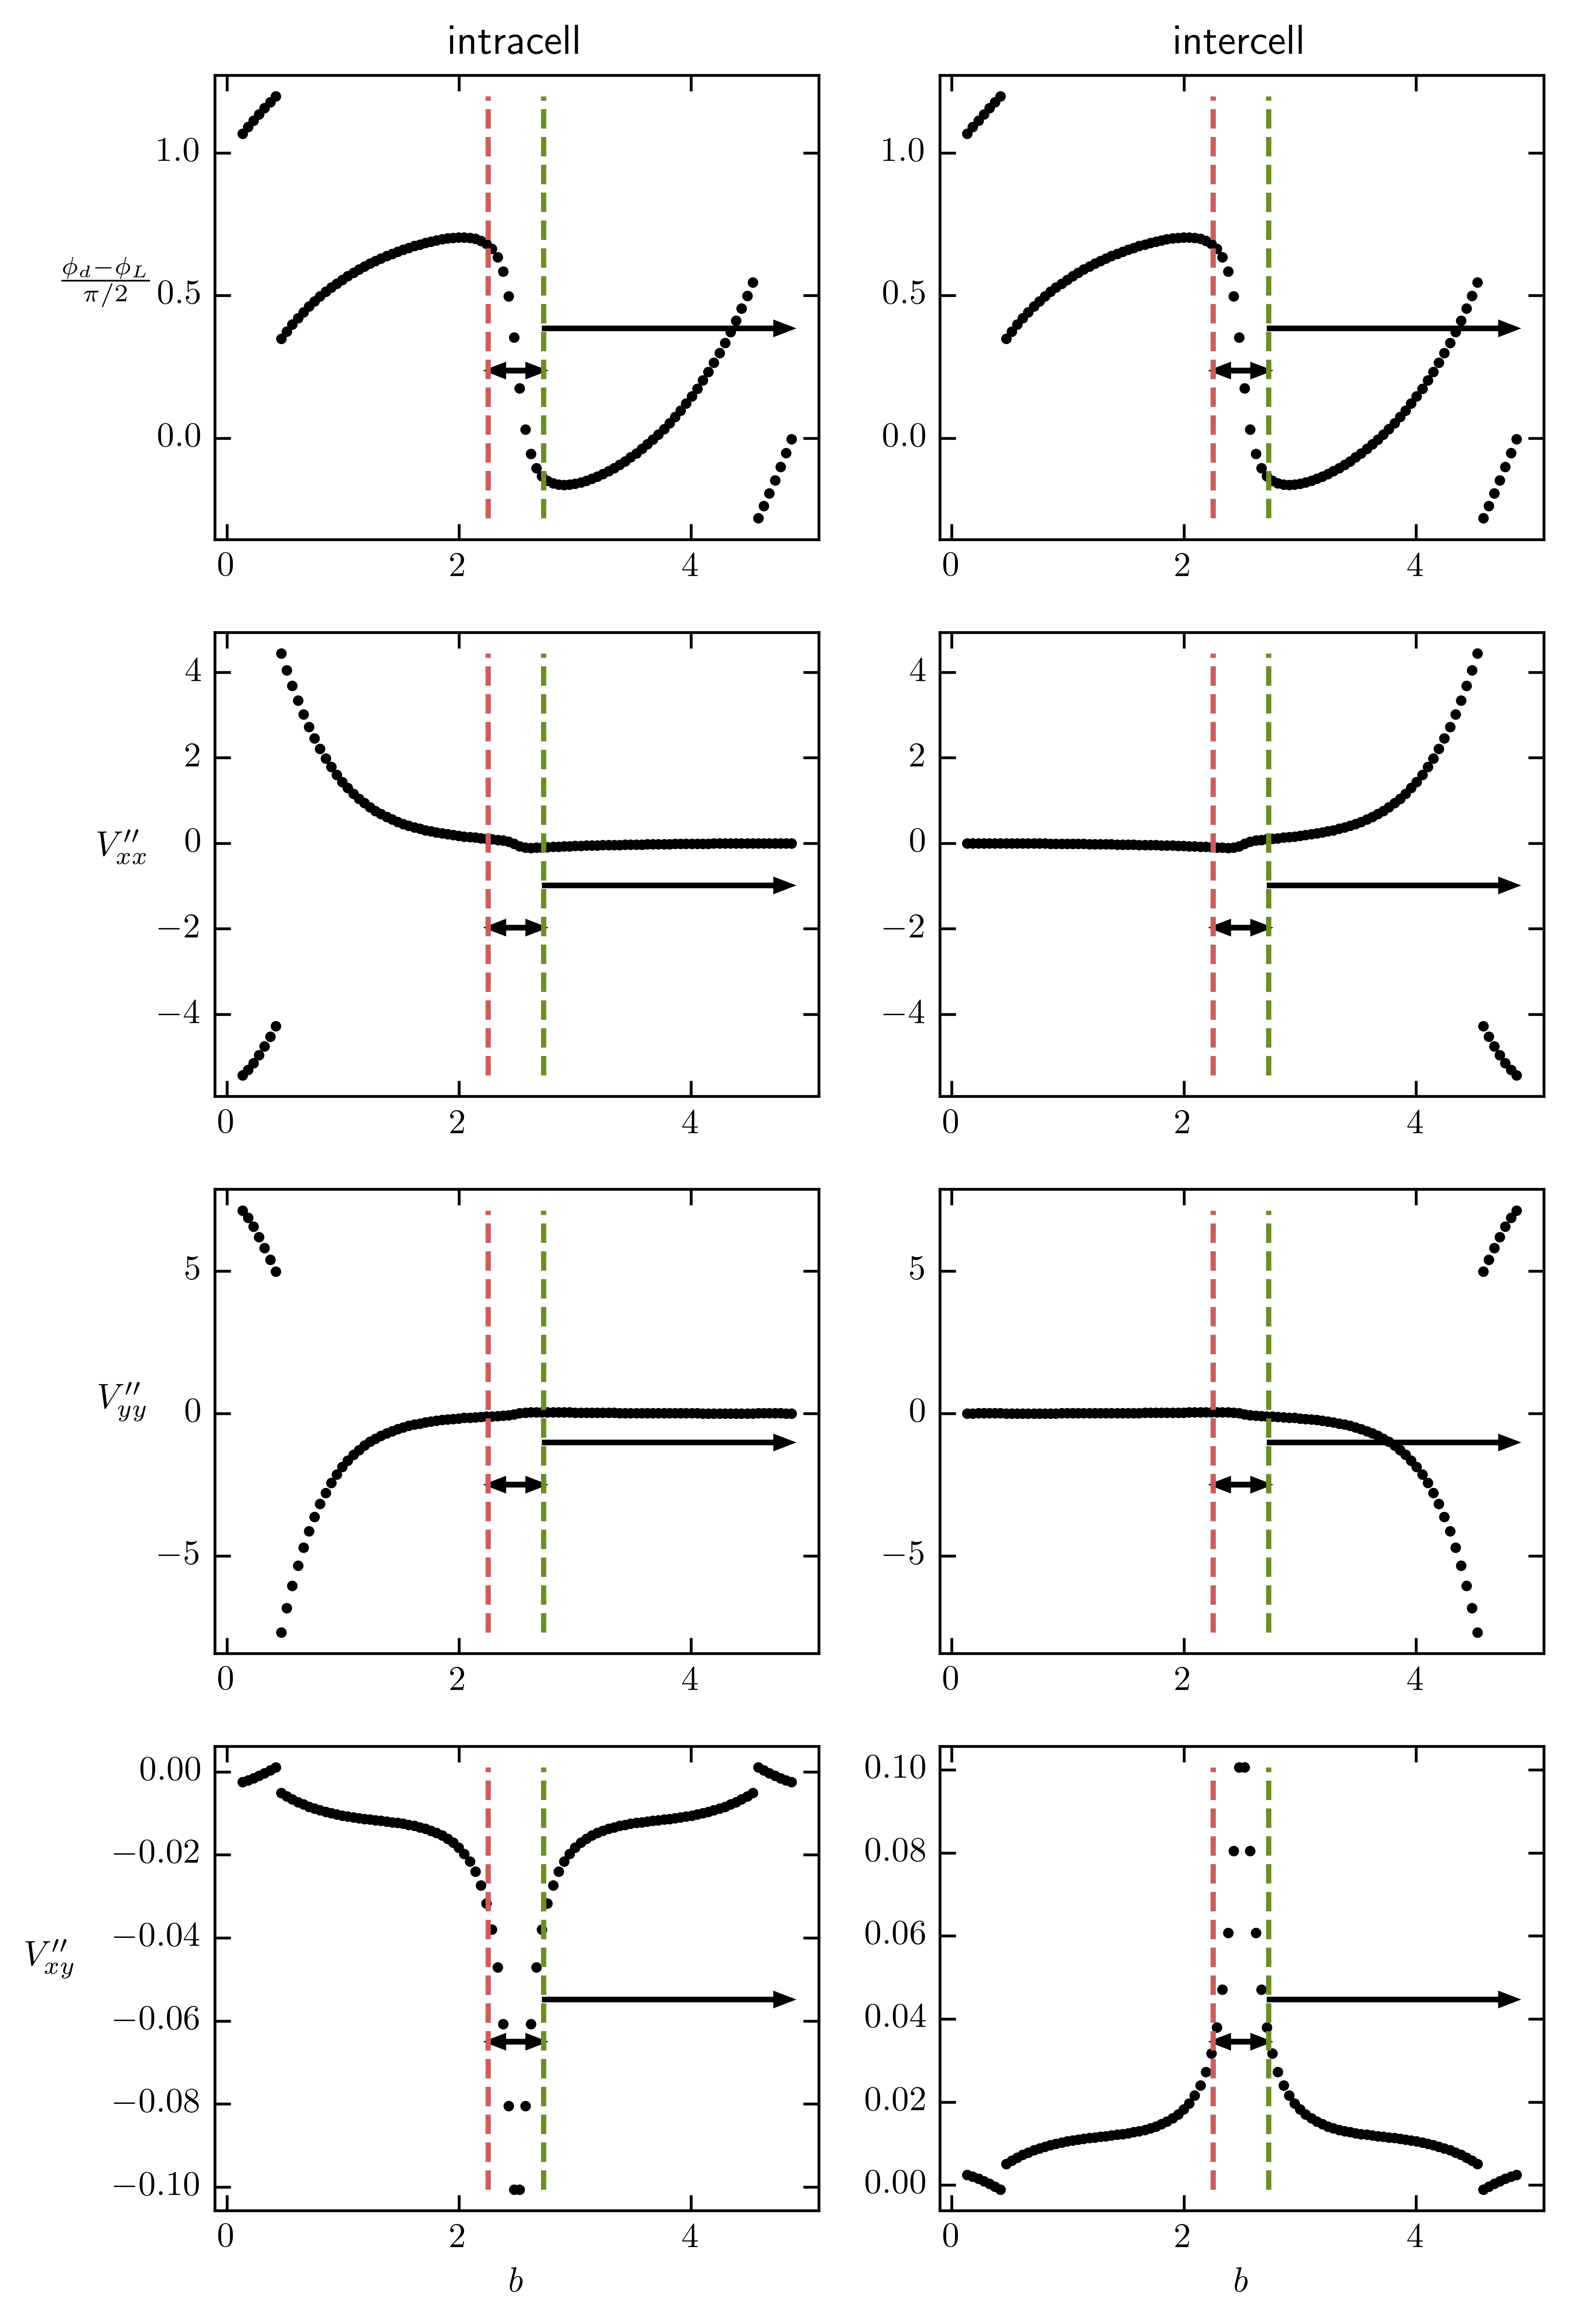

In [ ]:
tickp = TickProperties(SZX=False,SZY=False,\
                       xtick_step_major=20,\
                        xtick_step_minor=5,\
                            ytick_step_major=10,\
                                ytick_step_minor=5)
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',tickp=tickp)
setup.fig_height = 11
setup.fig_width =6.8


h = np.linspace(1.1,np.sqrt(0.75),4)
b = np.linspace(0,1,200)
b1 = b[:100]
b2 = b[100:][::-1]
ind = 1
a=5

# for i in range(len(h)):
for i in range(1):
    print(h[i])
    fig, ax = setup.return_fig(shape=(4,2),dots_per_inch=600,set_ticks=False,xax_share=True)#,joined=True
    # print(alphas[i])
    plt.rcParams["lines.markersize"]=2
    b = np.linspace(a-max_b(h[i],a),max_b(h[i],a),100)
    r1 = np.array([b,h[i]*np.ones(len(b))])
    r2 = np.array([b-a,h[i]*np.ones(len(b))])
    phi = np.arctan(h[i]/b)#/np.pi*2

    d = d_aligned(r1[0],r1[1],a)
    phi_d = np.arctan(d[1]/d[0])
    # for j in range(len(phi)):
    #     fig, ax = plt.subplots(1,1)
    #     ax.plot([0,d[0,j]],[0,d[1,j]])
    #     ax.plot([0,b[j]],[0,h[i]])
    r = [r1,r2]
    for j in range(2):
        ax[0,j].set_title(["intracell","intercell"][j])
        xy = interaction_aligned_dip(r[j],0,1,100,d)
        xx = interaction_aligned_dip(r[j],0,0,100,d)
        yy = interaction_aligned_dip(r[j],1,1,100,d)
        plots = [(phi-phi_d)/np.pi*2,xx,yy,xy]
        # ax.scatter(b,xy1)
        for ind in range(ax.shape[0]):
            s2 = 2.25
            s3 = 2.73
            # s3 = 0.7846
            ax[ind,j].scatter(b,plots[ind],color='0')
            # ax[ind,j].vlines(s1,min(plots[ind]),max(plots[ind]),color='indianred',linestyle='dashed')
            ax[ind,j].vlines(s2,min(plots[ind]),max(plots[ind]),color='indianred',linestyle='dashed')
            ax[ind,j].vlines(s3,min(plots[ind]),max(plots[ind]),color='olivedrab',linestyle='dashed')
            ratio = 0.65
            y_pos = (ratio*min(plots[ind])+(1-ratio)*max(plots[ind]))
            yscale = max(plots[ind])-min(plots[ind])
            xscale = b[-1]-b[0]
            
            ax[ind,j].arrow(x=s3,y=y_pos+0.1*yscale,dx=b[-1]-s3,dy=0,head_width=0.03*yscale,head_length=0.03*xscale,facecolor='0',length_includes_head=True,width=0.005*yscale)
            ax[ind,j].arrow(x=s2,y=y_pos,dx=s3-s2,dy=0,head_width=0.03*yscale,head_length=0.03*xscale,facecolor='0',length_includes_head=True,width=0.005*yscale)
            ax[ind,j].arrow(x=s3,y=y_pos,dx=s2-s3,dy=0,head_width=0.03*yscale,head_length=0.03*xscale,facecolor='0',length_includes_head=True,width=0.005*yscale)
            
            # ax[ind,j].scatter(b,plots[ind],color='0')
            # ax[ind,j].vlines(2.25,min(plots[ind]),max(plots[ind]),color='indianred',linestyle='dashed')
            # ax[ind,j].vlines(2.73,min(plots[ind]),max(plots[ind]),color='indianred',linestyle='dashed')
            # # ax[ind,j].vlines(0.697,min(plots[ind]),max(plots[ind]),color='indianred',linestyle='dashed')
            # ratio = 0.05
            # y_pos = (ratio*min(plots[ind])+(1-ratio)*max(plots[ind]))
            # yscale = max(plots[ind])-min(plots[ind])
            # xscale = b[-1]-b[0]
            # # print(yscale)
            # ax[ind,j].arrow(x=1.5,y=y_pos,dx=0.4,dy=0,head_width=0.03*yscale,head_length=0.03*xscale,facecolor='0',width=0.0005*yscale)
            # ax[ind,j].arrow(x=0.5,y=y_pos,dx=-0.5+0.303,dy=0,head_width=0.03*yscale,head_length=0.03*xscale,facecolor='0',length_includes_head=True),length_includes_head=True
            # ax[ind,j].arrow(x=0.697,y=y_pos,dx=b[-1]-0.697,dy=0,head_width=0.03*yscale,head_length=0.03*xscale,facecolor='0',length_includes_head=True)
                    
    ax[3,0].set_xlabel(r'$b$')
    ax[3,1].set_xlabel(r'$b$')
    ax[0,0].set_ylabel(r"$\frac{\phi_d-\phi_L}{\pi/2}$",rotation=0,labelpad=15)
    ax[1,0].set_ylabel(r"$V''_{xx}$",rotation=0,labelpad=10)
    ax[2,0].set_ylabel(r"$V''_{yy}$",rotation=0,labelpad=10)
    ax[3,0].set_ylabel(r"$V''_{xy}$",rotation=0,labelpad=18)

    # ax.scatter(b1,prop(b1,h[i])[ind]-prop(b2,h[i])[ind],s=30,label=f"+{h[i]}")
    # ax.scatter(b,d_aligned(b,h[i])[0],s=30,label=f"x{h[i]}")
    # ax.scatter(b,d_aligned(b,h[i])[1],s=30,label=f"y{h[i]}")
    # ax.legend()
    # plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"aligned_dipoles_in_plane_orientation_sheer_h1.1_a5.pdf",bbox_inches='tight',dpi=600)

    plt.show()


    

0.6
0.9


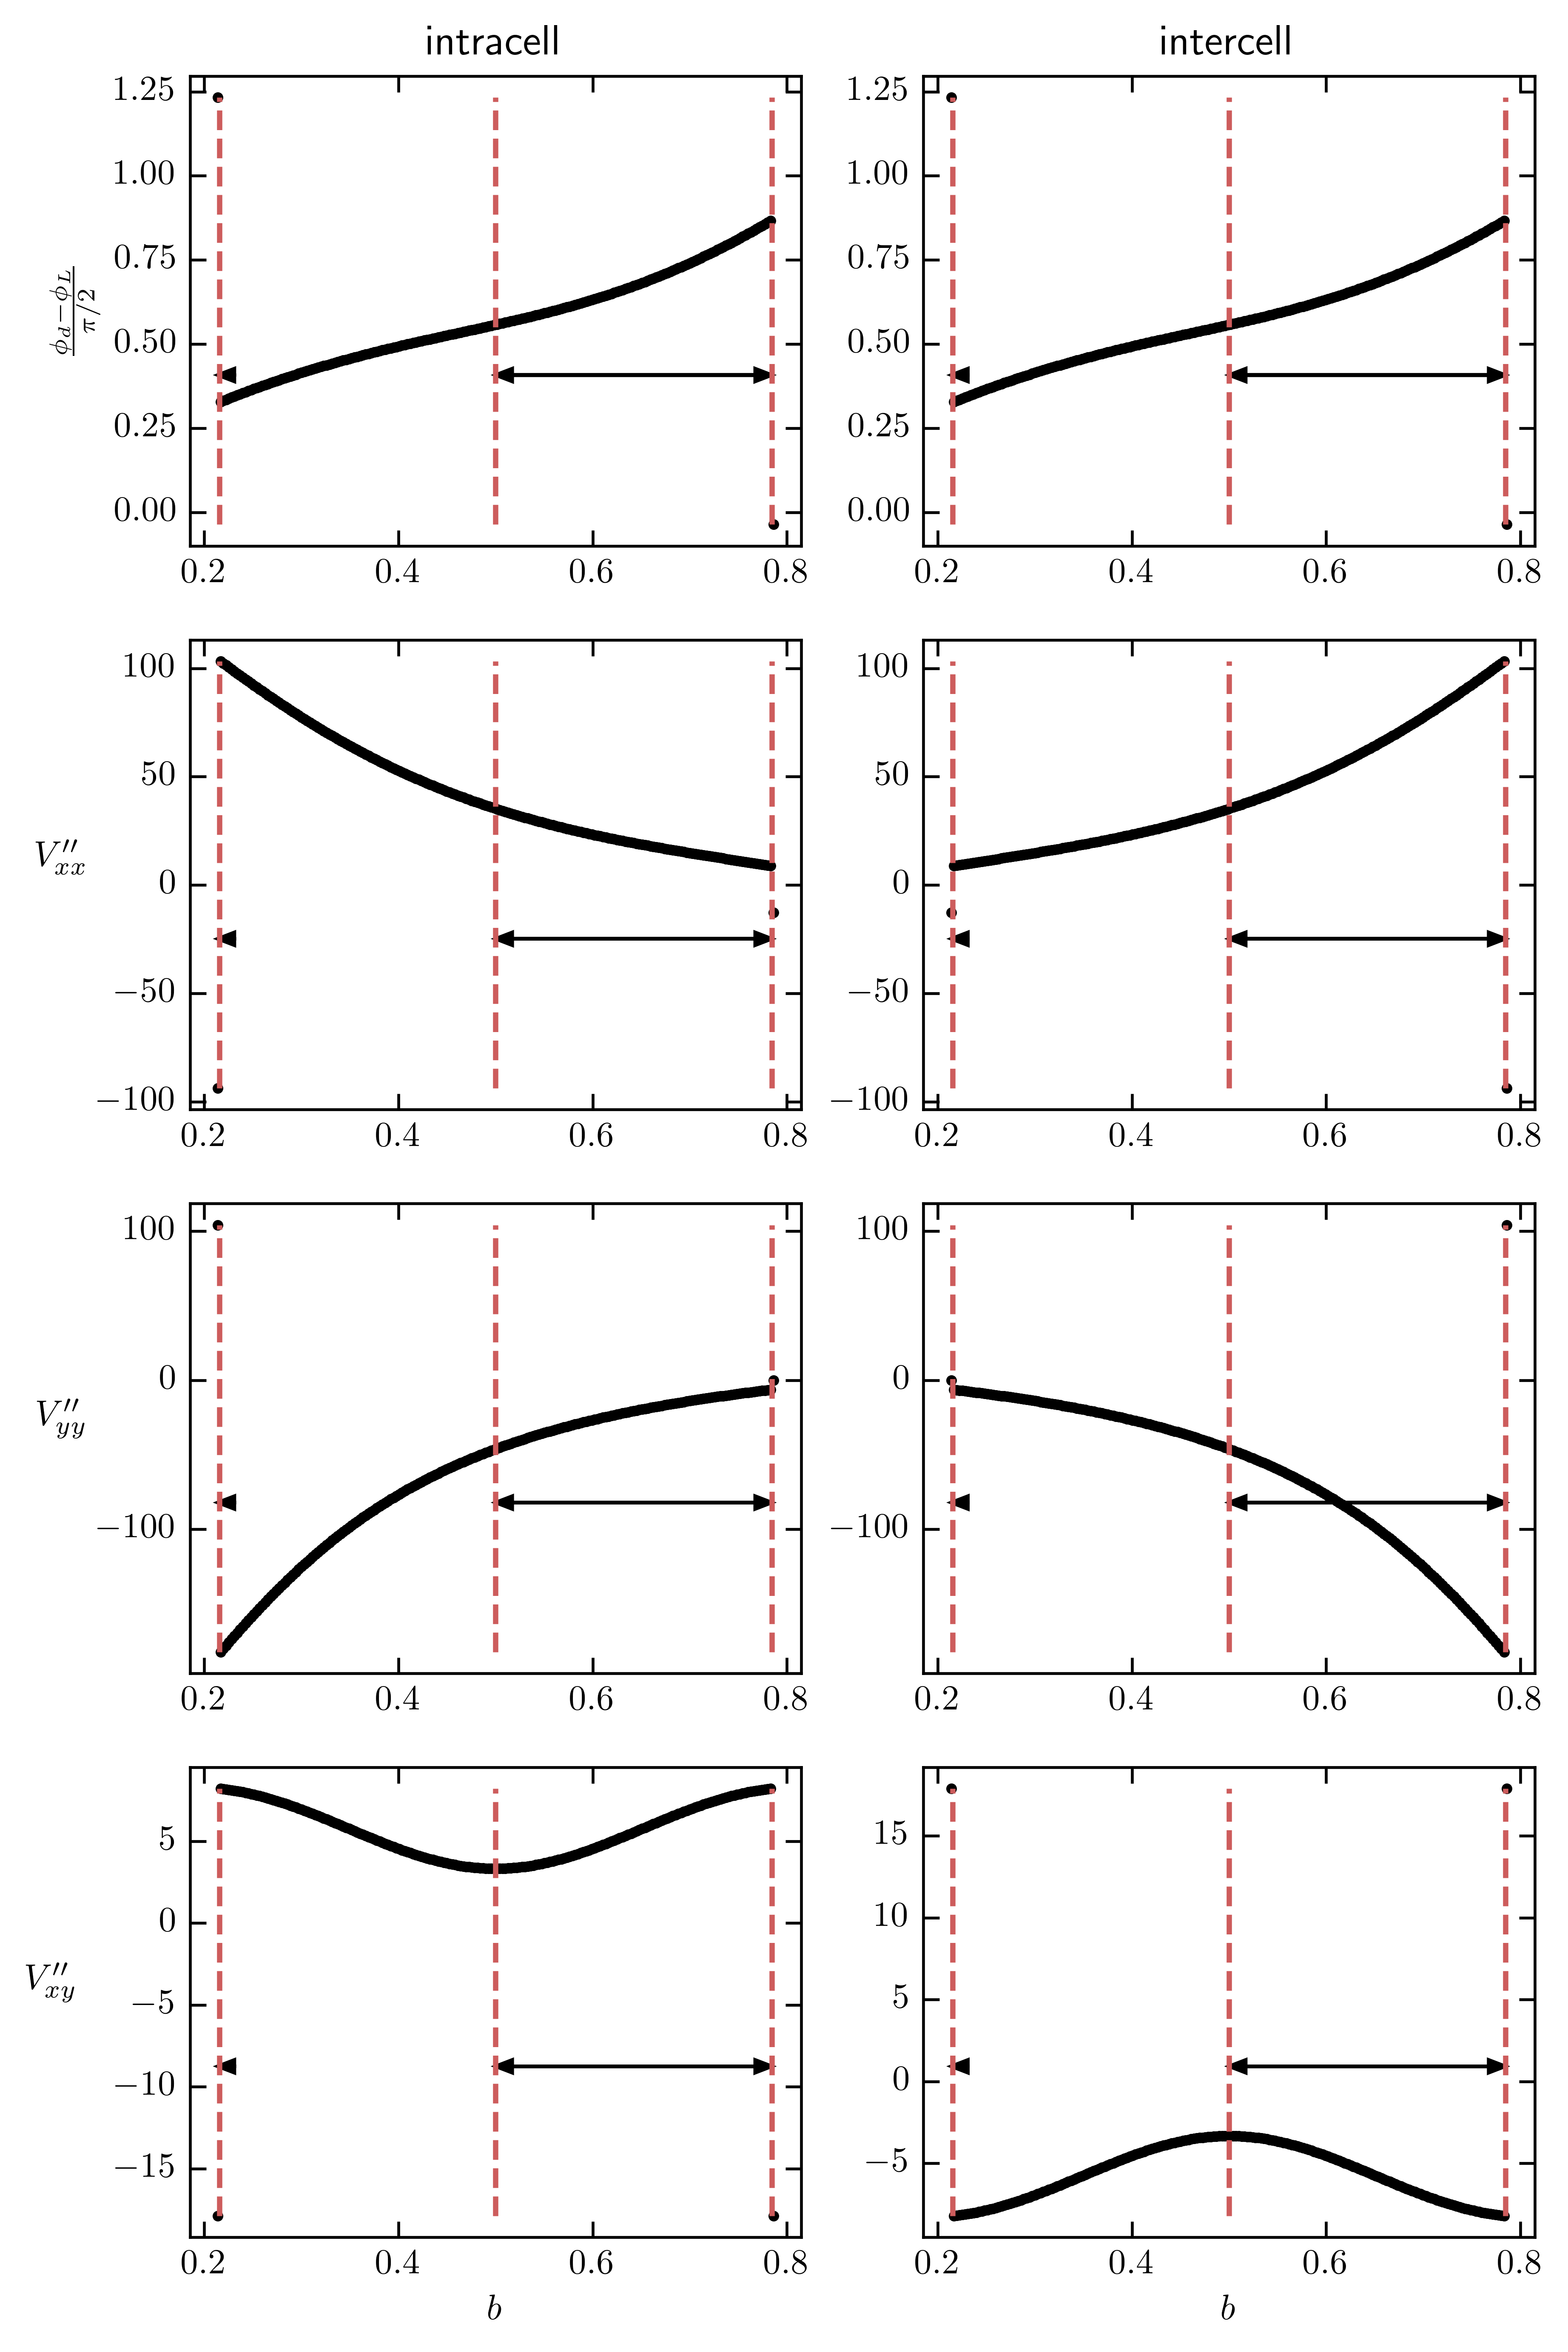

In [84]:
tickp = TickProperties(SZX=False,SZY=False,\
                       xtick_step_major=20,\
                        xtick_step_minor=5,\
                            ytick_step_major=10,\
                                ytick_step_minor=5)
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',tickp=tickp)
setup.fig_height = 11
setup.fig_width =6.8


h = np.linspace(0.6,np.sqrt(0.75),4)
b = np.linspace(0,1,200)
b1 = b[:100]
b2 = b[100:][::-1]
ind = 1

# for i in range(len(h)):
for i in range(1):
    print(h[i])
    fig, ax = setup.return_fig(shape=(4,2),dots_per_inch=600,set_ticks=False,xax_share=True)#,joined=True
    print(alphas[i])
    plt.rcParams["lines.markersize"]=2
    b = np.linspace(1-max_b(h[i]),max_b(h[i]),200)
    r1 = np.array([b,h[i]*np.ones(len(b))])
    r2 = np.array([b-1,h[i]*np.ones(len(b))])
    phi = np.arctan(h[i]/b)#/np.pi*2

    d = d_aligned(r1[0],r1[1])
    phi_d = np.arctan(d[1]/d[0])
    # for j in range(len(phi)):
    #     fig, ax = plt.subplots(1,1)
    #     ax.plot([0,d[0,j]],[0,d[1,j]])
    #     ax.plot([0,b[j]],[0,h[i]])
    r = [r1,r2]
    for j in range(2):
        ax[0,j].set_title(["intracell","intercell"][j])
        xy = interaction_aligned_dip(r[j],0,1,100,d)
        xx = interaction_aligned_dip(r[j],0,0,100,d)
        yy = interaction_aligned_dip(r[j],1,1,100,d)
        plots = [(phi-phi_d)/np.pi*2,xx,yy,xy]
        # ax.scatter(b,xy1)
        for ind in range(ax.shape[0]):
            s1 = 0.21537
            s2 = 0.5
            s3 = 0.7846
            ax[ind,j].scatter(b,plots[ind],color='0')
            ax[ind,j].vlines(s1,min(plots[ind]),max(plots[ind]),color='indianred',linestyle='dashed')
            ax[ind,j].vlines(s2,min(plots[ind]),max(plots[ind]),color='indianred',linestyle='dashed')
            ax[ind,j].vlines(s3,min(plots[ind]),max(plots[ind]),color='indianred',linestyle='dashed')
            ratio = 0.65
            y_pos = (ratio*min(plots[ind])+(1-ratio)*max(plots[ind]))
            yscale = max(plots[ind])-min(plots[ind])
            xscale = b[-1]-b[0]
            
            ax[ind,j].arrow(x=s1,y=y_pos,dx=b[0]-s1,dy=0,head_width=0.03*yscale,head_length=0.03*xscale,facecolor='0',length_includes_head=True)
            ax[ind,j].arrow(x=0.5,y=y_pos,dx=s3-s2,dy=0,head_width=0.03*yscale,head_length=0.03*xscale,facecolor='0',length_includes_head=True)
            ax[ind,j].arrow(x=s3,y=y_pos,dx=s2-s3,dy=0,head_width=0.03*yscale,head_length=0.03*xscale,facecolor='0',length_includes_head=True)
                    
    ax[3,0].set_xlabel(r'$b$')
    ax[3,1].set_xlabel(r'$b$')
    ax[0,0].set_ylabel(r"$\frac{\phi_d-\phi_L}{\pi/2}$")
    ax[1,0].set_ylabel(r"$V''_{xx}$",rotation=0,labelpad=10)
    ax[2,0].set_ylabel(r"$V''_{yy}$",rotation=0,labelpad=10)
    ax[3,0].set_ylabel(r"$V''_{xy}$",rotation=0,labelpad=18)

    # ax.scatter(b1,prop(b1,h[i])[ind]-prop(b2,h[i])[ind],s=30,label=f"+{h[i]}")
    # ax.scatter(b,d_aligned(b,h[i])[0],s=30,label=f"x{h[i]}")
    # ax.scatter(b,d_aligned(b,h[i])[1],s=30,label=f"y{h[i]}")
    # ax.legend()
    plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"aligned_dipoles_in_plane_zigzag_h0.6.pdf",bbox_inches='tight',dpi=600)

    plt.show()

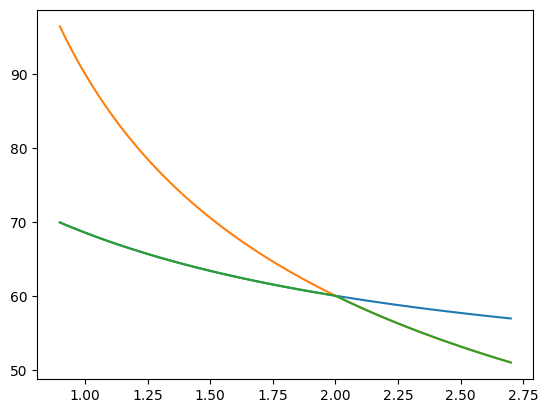

In [38]:
def fnc(r):
    return np.arccos((np.sqrt(1+2*r**2)-1)/2/r)/np.pi*180
def fnc2(r):
    return np.arccos((r-1)/r)/np.pi*180
def fnc3(r):
    return np.arcsin(np.sqrt(r**2-1)/r)/np.pi*180
def max_phi(r):
    return np.min(np.column_stack((np.arccos((np.sqrt(1+2*r**2)-1)/2/r)/np.pi*180,np.arccos((r-1)/r)/np.pi*180)),axis=1)
fig, ax = plt.subplots(1,1)
r = np.linspace(0.9,2.7,100)
ax.plot(r,fnc(r))
ax.plot(r,fnc2(r))
ax.plot(r,max_phi(r))
plt.show()

In [34]:
max_phi(r).shape

(100,)

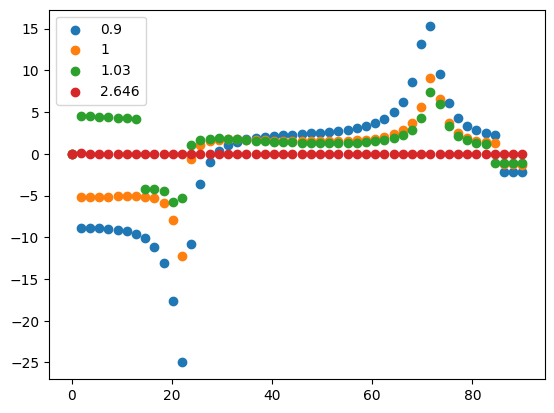

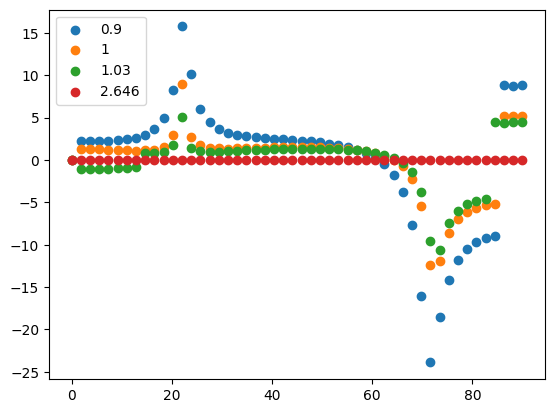

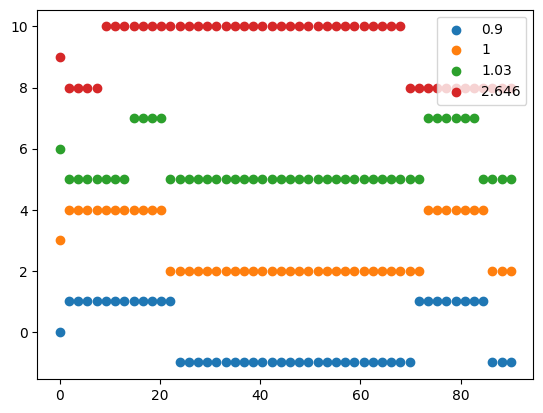

In [41]:
ig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
fig3, ax3 = plt.subplots(1,1)
x = np.linspace(0.08,0.12)
# phi = np.linspace(0,np.pi/2)
# phi = np.linspace(65,90)
# alphas = np.linspace(0.9,1.3,4)
d = 0.9

er = np.zeros((2,len(phi)))
er[0,:] = np.cos(phi/180*np.pi)
er[1,:] = np.sin(phi/180*np.pi)
for i in range(len(alphas)):
    yy = interaction_rotated(alphas[i]*er,1,1,d,100)
    xx = interaction_rotated(alphas[i]*er,0,0,d,100)
    # ax.scatter(phi,np.sqrt(xx**2+yy**2),label=f"{alphas[i]}")
    # ax2[i//2,i%2].scatter(phi,np.arctan(yy/xx)+np.sign(yy)*np.pi*(1-np.sign(xx))/2,label=f"{alphas[i]}")
    # ax2.scatter(phi,interaction_rotated(alphas[i]*er,0,0,d,100),label=f"{alphas[i]}")
    ax.scatter(phi,xx,label=f"{alphas[i]}")
    ax2.scatter(phi,yy,label=f"{alphas[i]}")
    # ax.scatter(x,vxx(alphas[i]*np.cos(phi),alphas[i]*np.sin(phi),d)[1],label=f"{alphas[i]}")
    # ax2.scatter(phi,vyy(alphas[i]*np.cos(phi),alphas[i]*np.sin(phi),d)[1],label=f"{alphas[i]}")
    # ax2[i//2,i%2].legend()
    ax3.scatter(phi,i*3+vyy(alphas[i]*np.sin(phi/180*np.pi),alphas[i]*np.cos(phi/180*np.pi),d)[0],label=f"{alphas[i]}")
    # ax3.scatter(phi,i*3+vyy(alphas[i]*np.sin(phi/180*np.pi),alphas[i]*np.cos(phi/180*np.pi),d)[0],label=f"{alphas[i]}")
ax.legend()
ax2.legend()
ax3.legend()
plt.show()

In [23]:
def bloch(t,delta,omega):
    w = np.sqrt(delta**2/4+omega**2)
    N = w/omega*2
    z = 1/2*(1-4*omega**2/delta**2)/(1+4*omega**2/delta**2)*np.sin(w*t)**2+np.cos(w*t)**2/2
    x = -delta/omega/N**2*2*np.sin(w*t)**2
    y = -2/N*np.sin(w*t)*np.cos(w*t)
    return np.array([x,y,z])

def rot_ax(t,delta,omega):
    return 

delta = 1
omega= 0.2
T = 2*np.pi/np.sqrt(delta**2/4+omega**2)*4
t = np.linspace(0,T)
# plt.figure()
# plt.plot(t,np.linalg.norm(bloch(t,delta,omega),axis=1))
# plt.show()

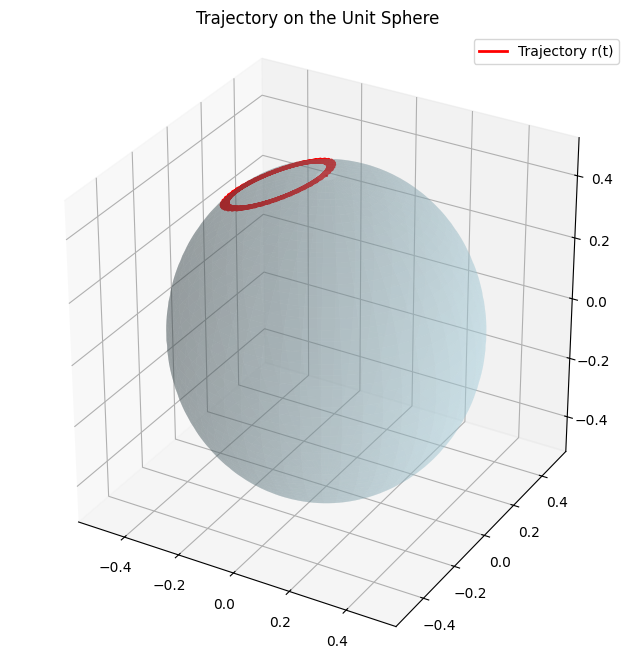

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define trajectory on the unit sphere
def trajectory(t, alpha=0.2):
    x = np.cos(t) * np.sin(alpha * t)
    y = np.sin(t) * np.sin(alpha * t)
    z = np.cos(alpha * t)
    return x, y, z

# Create parameter t
# t = np.linspace(0, 20*np.pi, 2000)
x, y, z = bloch(t,delta,omega)

# Create sphere surface
radius = 0.5
phi, theta = np.mgrid[0:np.pi:100j, 0:2*np.pi:100j]
x_sphere = np.sin(phi) * np.cos(theta)*radius
y_sphere = np.sin(phi) * np.sin(theta)*radius
z_sphere = np.cos(phi)*radius

# Plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot sphere surface
ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.3, linewidth=0)

# Plot trajectory
ax.plot(x, y, z, color='red', linewidth=2, label="Trajectory r(t)")

# Formatting
ax.set_box_aspect([1,1,1])
ax.set_title("Trajectory on the Unit Sphere")
ax.legend()
plt.show()


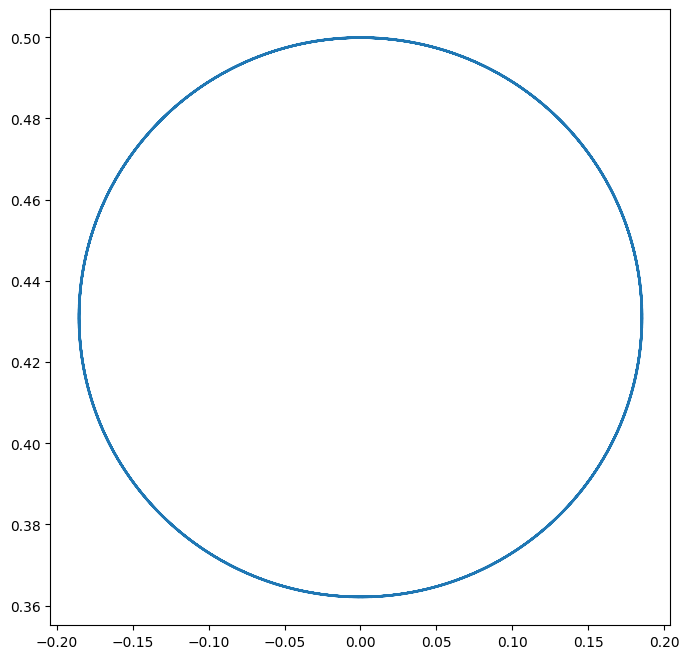

In [25]:
delta = 1
omega= 0.2
T = 2*np.pi/np.sqrt(delta**2/4+omega**2)*4
t = np.linspace(0,T,400)
x, y, z = bloch(t,delta,omega)

fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.plot(y,z)
plt.show()

/home/christian/Documents/master/python_env/lib/python3.12/site-packages/scipy/integrate/_ivp/ivp.py:621: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


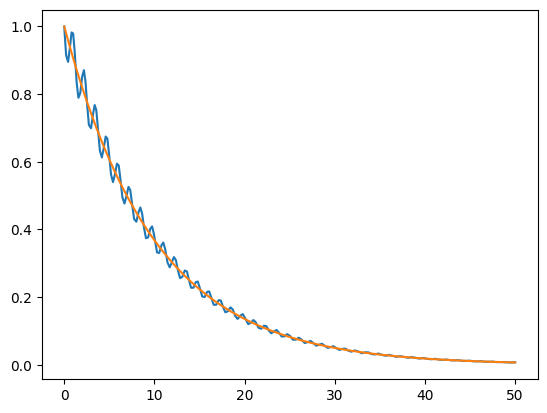

In [10]:
from scipy.integrate import solve_ivp
def kernel(t,x,A,B,w):
    dxdt = (-A-B*np.cos(w*t))*x
    return dxdt
a = 0.1
b = 4*a
w = 5
T= 5/a
sol = solve_ivp(kernel,[0,T],[1],args=(a,b,w),rtol=1e-15)
x = np.linspace(0,T,100)
plt.figure()
plt.plot(sol.t,sol.y[0])
plt.plot(x,np.exp(-a*x))
plt.show()